# StateGen Experiment Results — DeepSeek-V3

Compares **7 code generation strategies** on BigCodeBench (hard subset, 148 tasks).  
Model: **DeepSeek-V3** (`deepseek-chat` via `https://api.deepseek.com/v1`).  
> Note: experiments were submitted as `deepseek-coder` — this alias was deprecated in late 2024 and redirects to DeepSeek-V3 (`deepseek-chat`).

| Method | Description |
|---|---|
| `direct_gen` | Single LLM call, no retries |
| `self_planning` | Plan then generate, global retry on failure (Jiang et al. 2024) |
| `self_debugging` | Generate → explain → repair whole program (Chen et al. 2024) |
| `stategen` | **MDP decomposition with local state-level backtracking + memory** |
| `stategen_no_memory` | StateGen without the pattern memory cache (ablation) |
| `stategen_no_decompose` | StateGen without MDP decomposition — direct generate + repair (ablation) |
| `stategen_full_backtrack` | StateGen with full-program restart instead of local state repair (ablation) |

**Primary question:** Can StateGen match or exceed baseline pass@1 while using fewer tokens?  
**Ablation question:** Which StateGen components contribute most to its efficiency?

In [25]:
import json
import os
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── paths ──────────────────────────────────────────────────────────
ROOT = Path(".").resolve().parent  # notebook lives in notebooks/
if not (ROOT / "results").exists():
    ROOT = Path(".").resolve()     # fallback: run from project root
RESULTS = ROOT / "results" / "deepseek"

print(f"Results directory: {RESULTS}")
print("Files:", [p.name for p in RESULTS.glob("*") if p.is_file()])

Results directory: /Users/mac/Documents/cmu/spring26/intro-deep-learning/project/stategen/results/deepseek
Files: ['metrics.json', 'plot_input_output_tokens.png', 'plot_time_tradeoff.png', 'self_planning_solutions.jsonl', 'plot_token_distribution.png', 'plot_retries.png', 'plot_overhead.png', 'plot_pass_vs_tokens.png', 'plot_wall_time.png', 'plot_official_vs_proxy.png', 'token_events.jsonl', 'plot_task_heatmap.png', 'plot_memory_reuse.png', 'stategen_solutions.jsonl', 'plot_pareto_scatter.png', 'plot_call_type_tokens.png', 'plot_ablation_bars.png', 'stategen_full_backtrack_solutions.jsonl', 'manifest.json', 'self_debugging_solutions.jsonl', 'stategen_no_memory_solutions.jsonl', 'stategen_no_decompose_solutions.jsonl', 'direct_gen_solutions.jsonl']


In [26]:
# ── style ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})

# Baselines first, then stategen variants
METHOD_ORDER = [
    "direct_gen",
    "self_planning",
    "self_debugging",
    "stategen",
    "stategen_no_memory",
    "stategen_no_decompose",
    "stategen_full_backtrack",
]
METHOD_LABELS = {
    "direct_gen":              "Direct Gen",
    "self_planning":           "Self-Planning",
    "self_debugging":          "Self-Debugging",
    "stategen":                "StateGen (ours)",
    "stategen_no_memory":      "StateGen\n(no memory)",
    "stategen_no_decompose":   "StateGen\n(no decomp)",
    "stategen_full_backtrack": "StateGen\n(full backtrack)",
}
# Short labels for tight axis ticks
SHORT_LABELS = {
    "direct_gen":              "Direct",
    "self_planning":           "Self-Plan",
    "self_debugging":          "Self-Debug",
    "stategen":                "StateGen",
    "stategen_no_memory":      "No Memory",
    "stategen_no_decompose":   "No Decomp",
    "stategen_full_backtrack": "Full BT",
}
PALETTE = {
    "direct_gen":              "#7eb0d5",
    "self_planning":           "#fd7f6f",
    "self_debugging":          "#b2e061",
    "stategen":                "#bd7ebe",
    "stategen_no_memory":      "#ffb55a",
    "stategen_no_decompose":   "#8be0e8",
    "stategen_full_backtrack": "#e88bc0",
}
# Ablation methods for grouping in ablation section
ABLATION_METHODS = ["stategen", "stategen_no_memory", "stategen_no_decompose", "stategen_full_backtrack"]

In [27]:
# ── load per-task solution records ─────────────────────────────────
records = []
for path in RESULTS.glob("*_solutions.jsonl"):
    method = path.stem.replace("_solutions", "")
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rec = json.loads(line)
                rec.setdefault("method", method)
                records.append(rec)

df_all = pd.DataFrame(records)

# ── restrict to the common task set across all methods ──────────────
# (self_debugging timed out on 3 tasks; all 3 fail on every other method)
task_sets = df_all.groupby("method")["task_id"].apply(set)
common_tasks = set.intersection(*task_sets.values)
df = df_all[df_all["task_id"].isin(common_tasks)].copy()

n_all    = df_all["task_id"].nunique()
n_common = len(common_tasks)
dropped  = n_all - n_common
print(f"Total unique tasks: {n_all}  |  Common to all methods: {n_common}  |  Dropped: {dropped}")
if dropped:
    dropped_ids = set(df_all["task_id"].unique()) - common_tasks
    print(f"  Excluded: {sorted(dropped_ids)}")
print(f"Methods: {sorted(df['method'].unique())}")
df.head(3)

Total unique tasks: 148  |  Common to all methods: 145  |  Dropped: 3
  Excluded: ['BigCodeBench/108', 'BigCodeBench/120', 'BigCodeBench/123']
Methods: ['direct_gen', 'self_debugging', 'self_planning', 'stategen', 'stategen_full_backtrack', 'stategen_no_decompose', 'stategen_no_memory']


,task_id,solution,method,total_input_tokens,total_output_tokens,total_tokens,num_attempts,num_retries,wall_time,attempt_details
0,BigCodeBench/13,import subprocess\nimport ftplib\nimport os\n\...,self_planning,1029,475,1504,2,0,36.153325,"[{'attempt': 0, 'passed': True, 'error': '', '..."
1,BigCodeBench/15,import subprocess\nimport csv\nimport os\n\nde...,self_planning,1527,1260,2787,4,2,75.207793,"[{'attempt': 0, 'passed': False, 'error': 'Ass..."
2,BigCodeBench/17,import subprocess\nimport psutil\nimport time\...,self_planning,1595,1089,2684,6,4,61.336942,"[{'attempt': 0, 'passed': False, 'error': '? ..."


In [28]:
# ── load token events (per LLM call) ───────────────────────────────
events = []
tok_path = RESULTS / "token_events.jsonl"
if tok_path.exists():
    with open(tok_path) as f:
        for line in f:
            line = line.strip()
            if line:
                events.append(json.loads(line))
df_events = pd.DataFrame(events) if events else pd.DataFrame()
print(f"Token events: {len(df_events)} rows")
if not df_events.empty:
    print(df_events.groupby(["method", "call_type"]).size().unstack(fill_value=0))

Token events: 1789 rows
call_type                decomposition  final_repair  generation  repair
method                                                                  
stategen_full_backtrack            148           245           0     296
stategen_no_decompose                0           257         148       0
stategen_no_memory                 148           251           0     296


In [29]:
# ── load official eval status if available ──────────────────────────
# Each method can have results from BCB's Docker evaluator:
#   results/{method}_solutions-sanitized-calibrated_eval_results.json
eval_status = {}   # task_id → "pass" | "fail" | ...
for path in RESULTS.glob("*_eval_results.json"):
    with open(path) as f:
        data = json.load(f)
    for task_id, results in data.get("eval", {}).items():
        if results:
            eval_status[task_id] = results[0]["status"]

print(f"Official eval results loaded for {len(eval_status)} tasks" if eval_status
      else "No official eval results yet — using quick_check proxy for pass@1")

No official eval results yet — using quick_check proxy for pass@1


In [30]:
# ── compute per-task pass column ────────────────────────────────────
# Intermediate call types don't represent a final solve attempt
_INTERMEDIATE_TYPES = {"decomp_verify", "decomposition", "memory_hit"}

def task_passed(row):
    if eval_status:
        return eval_status.get(row["task_id"], "fail") == "pass"
    details = row.get("attempt_details", [])
    if not details:
        return False
    # Pass if any non-intermediate attempt succeeded
    return any(
        d.get("passed")
        for d in details
        if d.get("call_type") not in _INTERMEDIATE_TYPES
    )

df["passed"] = df.apply(task_passed, axis=1)
df["total_tokens"] = df.get("total_tokens", df["total_input_tokens"] + df["total_output_tokens"])

# filter to methods present in data, in canonical order
avail = [m for m in METHOD_ORDER if m in df["method"].values]
df = df[df["method"].isin(avail)].copy()

summary = (
    df.groupby("method")
    .agg(
        n_tasks=("task_id", "count"),
        pass_at_1=("passed", "mean"),
        avg_tokens=("total_tokens", "mean"),
        median_tokens=("total_tokens", "median"),
        avg_retries=("num_retries", "mean"),
        avg_wall_time=("wall_time", "mean"),
    )
    .reindex([m for m in avail])
)
summary["label"]       = summary.index.map(METHOD_LABELS)
summary["short_label"] = summary.index.map(SHORT_LABELS)
print(summary[["n_tasks", "pass_at_1", "avg_tokens", "avg_retries", "avg_wall_time"]].to_string())

                         n_tasks  pass_at_1   avg_tokens  avg_retries  avg_wall_time
method                                                                              
direct_gen                   145   0.234483   603.593103     0.000000      18.980656
self_planning                145   0.289655  3178.068966     3.020690      86.794611
self_debugging               145   0.303448  6560.275862     1.475862     140.014758
stategen                     145   0.303448  3093.441379     1.800000      74.370305
stategen_no_memory           145   0.282759  3426.055172     4.689655      50.692993
stategen_no_decompose        145   0.296552  2336.531034     1.731034      38.353270
stategen_full_backtrack      145   0.303448  3333.882759     4.648276      42.292332


## 1. Pass@1 vs Token Cost

The primary trade-off: correctness vs. token cost.

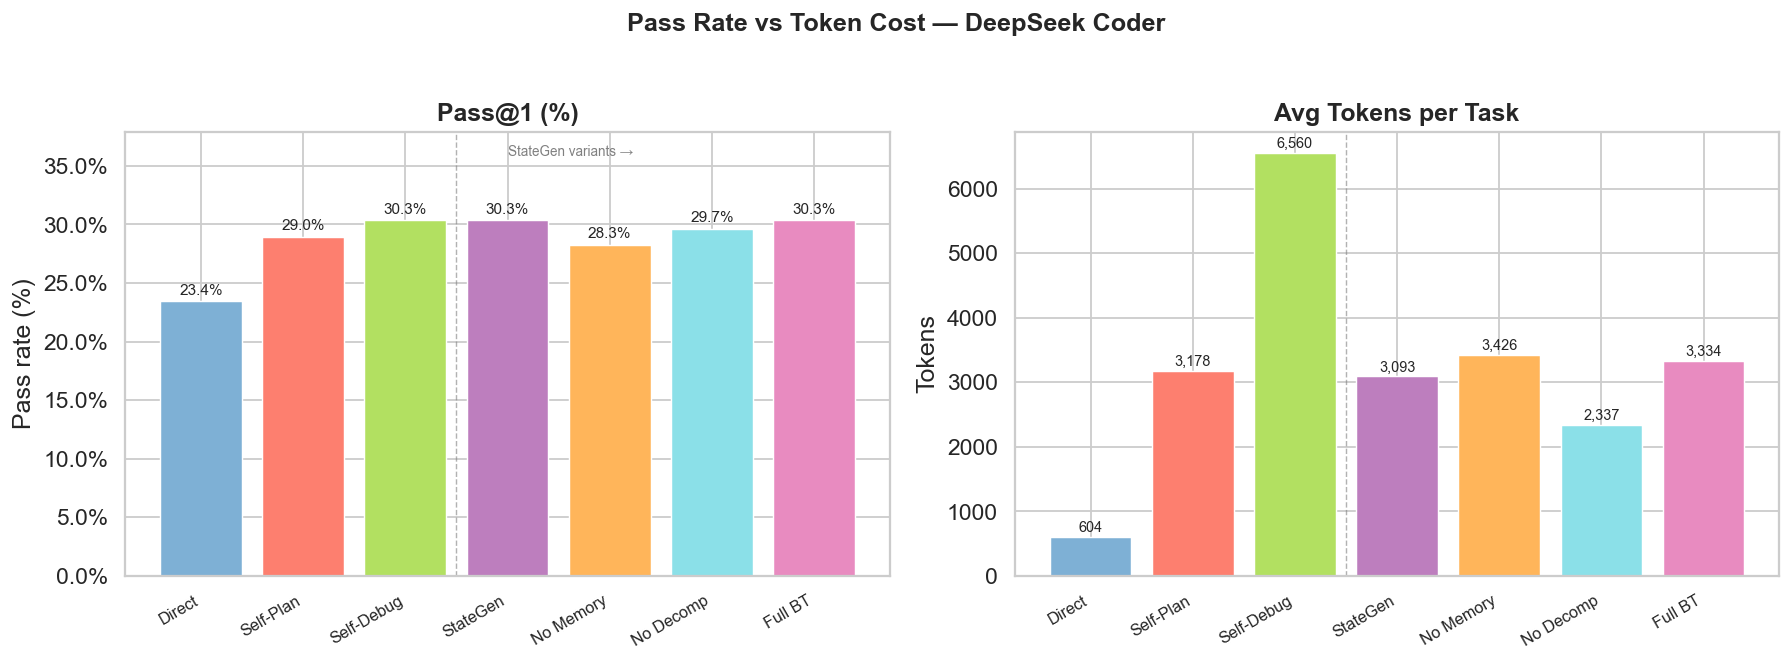

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = [m for m in avail]
slabels = [SHORT_LABELS[m] for m in methods]
colors  = [PALETTE[m] for m in methods]
x       = np.arange(len(methods))

# ── (a) pass@1 ──────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, summary.loc[methods, "pass_at_1"] * 100,
              color=colors, edgecolor="white", linewidth=0.8)
ax.set_title("Pass@1 (%)", fontweight="bold")
ax.set_ylabel("Pass rate (%)")
ax.set_ylim(0, max(summary["pass_at_1"].max() * 125, 15))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticks(x)
ax.set_xticklabels(slabels, rotation=30, ha="right", fontsize=9)
for bar, val in zip(bars, summary.loc[methods, "pass_at_1"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1%}", ha="center", va="bottom", fontsize=8.5)
# Vertical line separating baselines from StateGen variants
ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(3.0, ax.get_ylim()[1] * 0.97, "StateGen variants →",
        fontsize=7.5, color="grey", va="top")

# ── (b) avg tokens ───────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(x, summary.loc[methods, "avg_tokens"],
              color=colors, edgecolor="white", linewidth=0.8)
ax.set_title("Avg Tokens per Task", fontweight="bold")
ax.set_ylabel("Tokens")
ax.set_xticks(x)
ax.set_xticklabels(slabels, rotation=30, ha="right", fontsize=9)
for bar, val in zip(bars, summary.loc[methods, "avg_tokens"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=8)
ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.suptitle("Pass Rate vs Token Cost — DeepSeek Coder", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / "plot_pass_vs_tokens.png", bbox_inches="tight")
plt.show()

## 2. Per-Task Token Distribution

Box plots show how token costs vary across tasks (outliers indicate hard problems or excessive retrying).

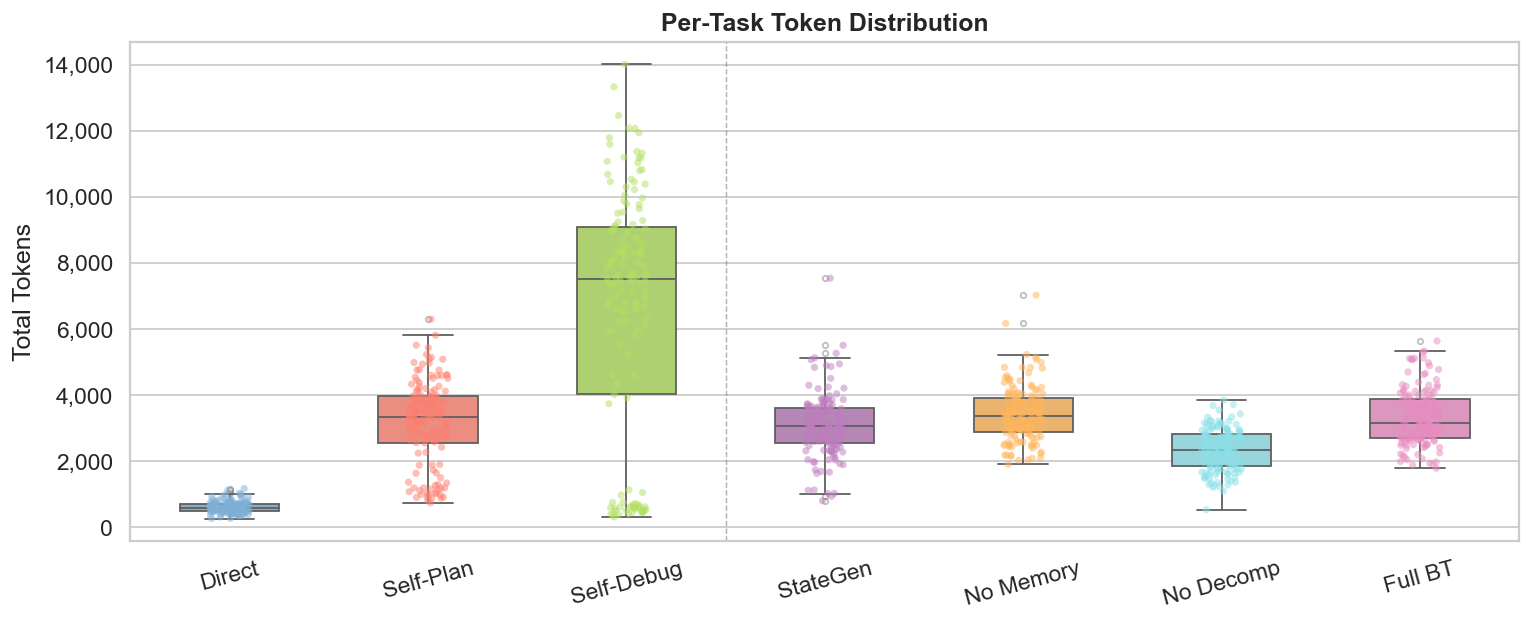

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))

plot_df = df[df["method"].isin(avail)].copy()
plot_df["Method"] = plot_df["method"].map(SHORT_LABELS)
order = [SHORT_LABELS[m] for m in avail]
pal   = {SHORT_LABELS[m]: PALETTE[m] for m in avail}

sns.boxplot(
    data=plot_df, x="Method", y="total_tokens",
    order=order, hue="Method", palette=pal, width=0.5, legend=False,
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
    ax=ax,
)
sns.stripplot(
    data=plot_df, x="Method", y="total_tokens",
    order=order, hue="Method", palette=pal, size=4, alpha=0.5,
    jitter=True, legend=False, ax=ax,
)

ax.set_title("Per-Task Token Distribution", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Total Tokens")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", labelrotation=15)
ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(RESULTS / "plot_token_distribution.png", bbox_inches="tight")
plt.show()

## 3. Token Breakdown: Input vs Output

Input tokens dominate cost for methods that re-feed the entire program in repair prompts (self-debugging). Output tokens are similar across methods.

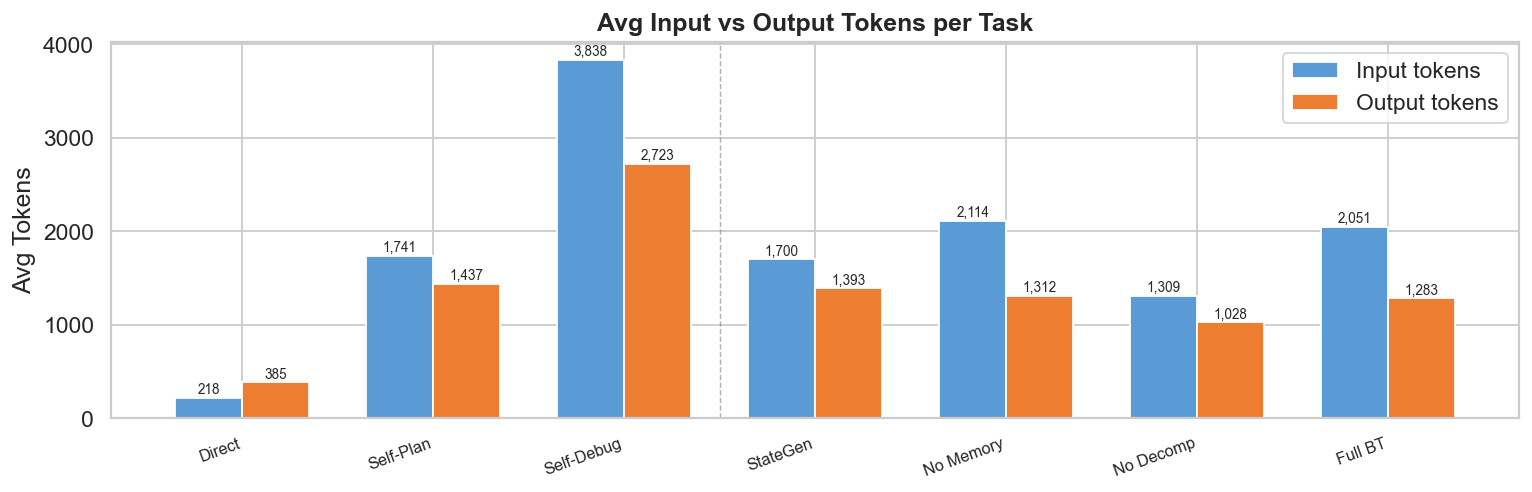

In [33]:
fig, ax = plt.subplots(figsize=(12, 4))

x = np.arange(len(avail))
w = 0.35

avg_in  = [df[df["method"]==m]["total_input_tokens"].mean()  for m in avail]
avg_out = [df[df["method"]==m]["total_output_tokens"].mean() for m in avail]

b1 = ax.bar(x - w/2, avg_in,  w, label="Input tokens",  color="#5b9bd5", edgecolor="white")
b2 = ax.bar(x + w/2, avg_out, w, label="Output tokens", color="#ed7d31", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([SHORT_LABELS[m] for m in avail], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Avg Tokens")
ax.set_title("Avg Input vs Output Tokens per Task", fontweight="bold")
ax.legend()
ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 10, f"{h:,.0f}",
            ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig(RESULTS / "plot_input_output_tokens.png", bbox_inches="tight")
plt.show()

## 4. Token Overhead vs Direct Generation

How much more (or less) does each method cost relative to the `direct_gen` baseline?

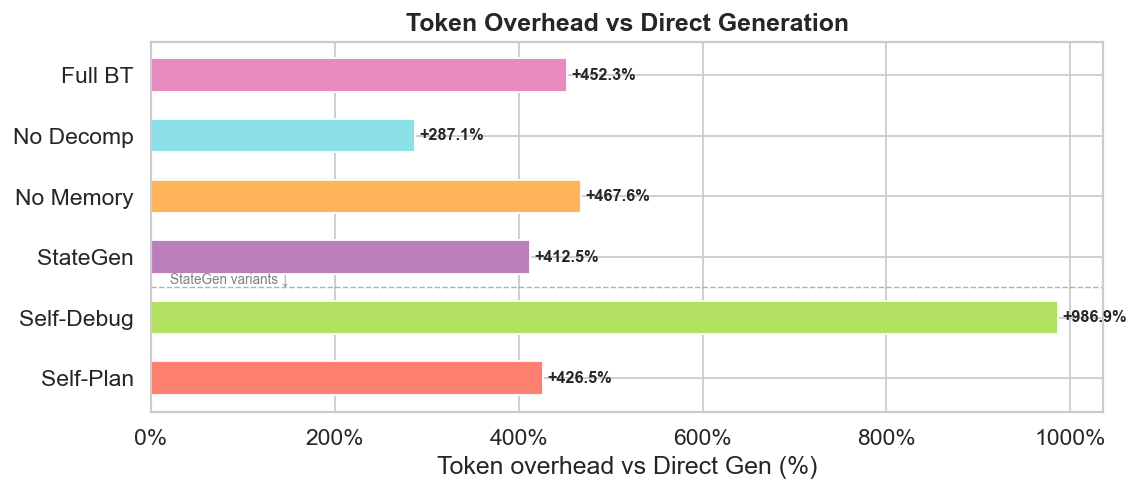

In [34]:
direct_avg = df[df["method"]=="direct_gen"]["total_tokens"].mean() if "direct_gen" in avail else None

if direct_avg:
    fig, ax = plt.subplots(figsize=(9, 4))

    non_direct = [m for m in avail if m != "direct_gen"]
    overheads  = [
        (df[df["method"]==m]["total_tokens"].mean() / direct_avg - 1) * 100
        for m in non_direct
    ]
    bar_colors = [PALETTE[m] for m in non_direct]

    bars = ax.barh([SHORT_LABELS[m] for m in non_direct], overheads,
                   color=bar_colors, edgecolor="white", height=0.55)
    ax.axvline(0, color="grey", linewidth=1)
    ax.set_xlabel("Token overhead vs Direct Gen (%)")
    ax.set_title("Token Overhead vs Direct Generation", fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())

    for bar, val in zip(bars, overheads):
        xpos = val + 5
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f"{val:+.1f}%", va="center", ha="left",
                fontsize=9, fontweight="bold")

    # Separator line between baselines and StateGen variants
    n_baselines = sum(1 for m in non_direct if m not in ABLATION_METHODS)
    ax.axhline(n_baselines - 0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(ax.get_xlim()[1] * 0.02, n_baselines - 0.45,
            "StateGen variants ↓", fontsize=7.5, color="grey")

    plt.tight_layout()
    plt.savefig(RESULTS / "plot_overhead.png", bbox_inches="tight")
    plt.show()
else:
    print("direct_gen results not found — skipping overhead chart")

## 5. Token Cost by Call Type

Breaks down where tokens are spent inside each method (generation, planning, explanation, repair, etc.).

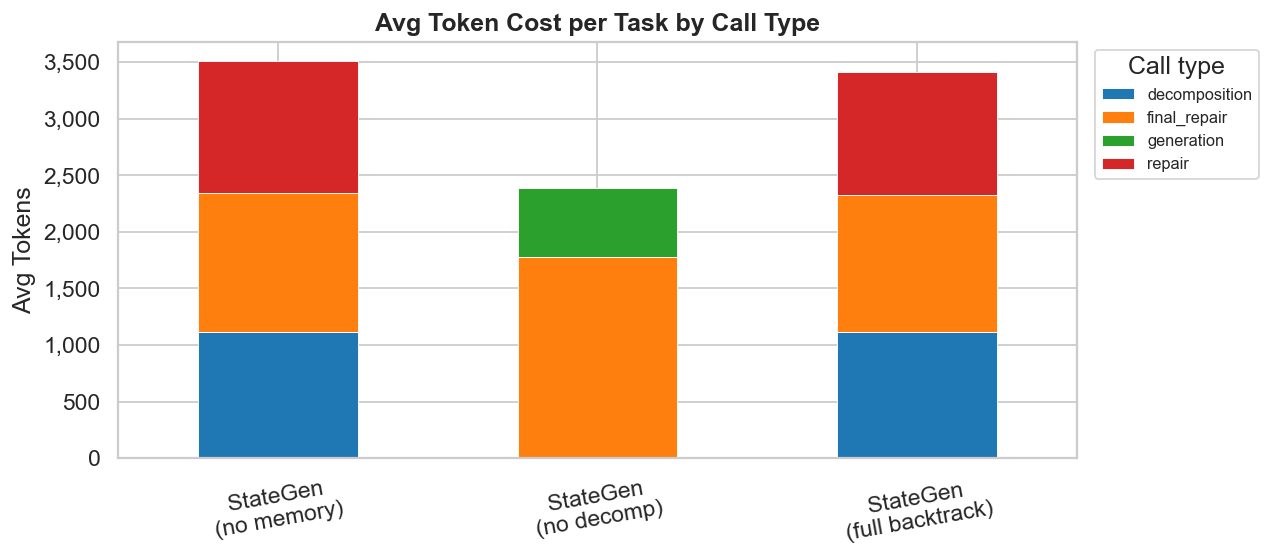

In [35]:
if not df_events.empty:
    df_events["total_tokens"] = df_events["input_tokens"] + df_events["output_tokens"]

    # Per-method average token cost by call_type
    ct_avg = (
        df_events.groupby(["method", "call_type"])["total_tokens"]
        .sum()
        .reset_index()
        .pivot(index="method", columns="call_type", values="total_tokens")
        .fillna(0)
    )
    # Normalize per task
    task_counts = df.groupby("method")["task_id"].count()
    ct_avg = ct_avg.div(task_counts, axis=0).reindex([m for m in avail if m in ct_avg.index])
    ct_avg.index = [METHOD_LABELS[m] for m in ct_avg.index]

    # Drop near-zero columns
    ct_avg = ct_avg.loc[:, ct_avg.max() > 10]

    cmap = plt.get_cmap("tab10")
    call_colors = {c: cmap(i) for i, c in enumerate(ct_avg.columns)}

    ax = ct_avg.plot(
        kind="bar", stacked=True, figsize=(10, 4.5),
        color=[call_colors[c] for c in ct_avg.columns],
        edgecolor="white", linewidth=0.5,
    )
    ax.set_title("Avg Token Cost per Task by Call Type", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Avg Tokens")
    ax.tick_params(axis="x", labelrotation=10)
    ax.legend(title="Call type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    plt.tight_layout()
    plt.savefig(RESULTS / "plot_call_type_tokens.png", bbox_inches="tight")
    plt.show()
else:
    print("No token_events.jsonl found — skipping call-type breakdown")

## 6. Retry Behaviour

How many retries does each method use on average, and does retrying help?

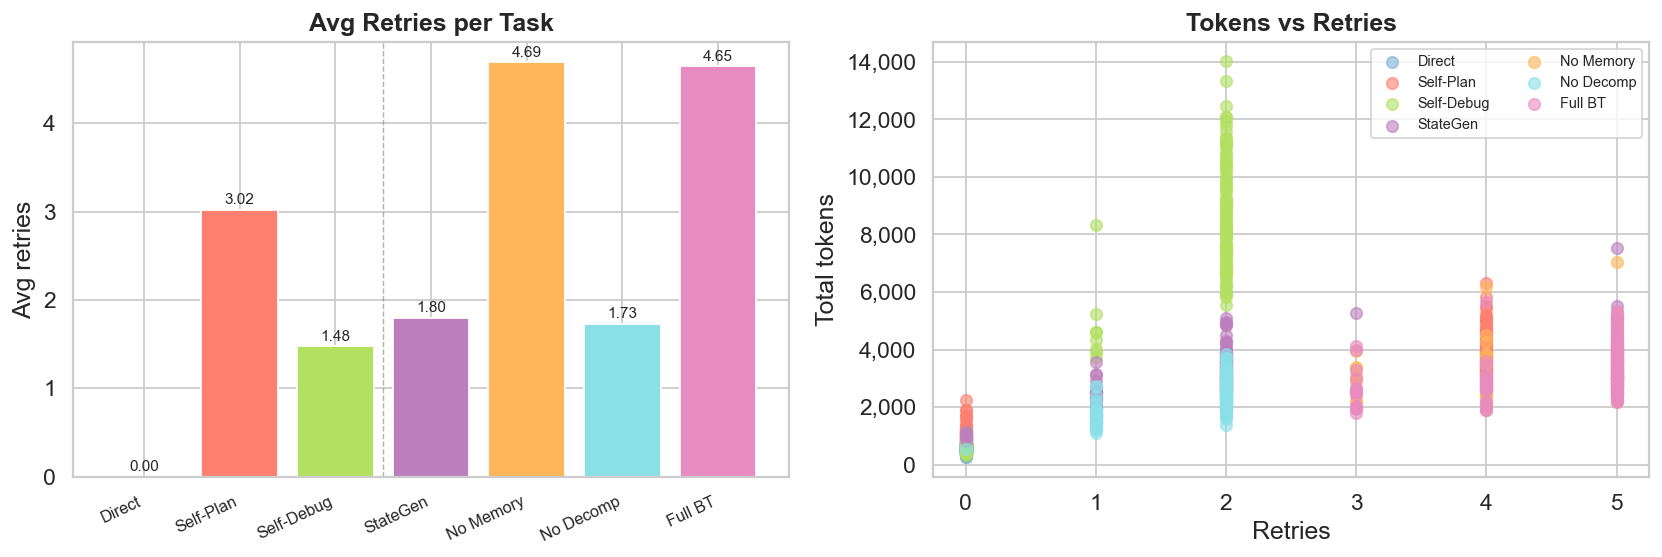

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── (a) Avg retries per method ────────────────────────────────────────
ax = axes[0]
retries = [summary.loc[m, "avg_retries"] for m in avail]
bars = ax.bar(np.arange(len(avail)), retries,
              color=[PALETTE[m] for m in avail], edgecolor="white")
ax.set_xticks(np.arange(len(avail)))
ax.set_xticklabels([SHORT_LABELS[m] for m in avail], rotation=25, ha="right", fontsize=9)
ax.set_title("Avg Retries per Task", fontweight="bold")
ax.set_ylabel("Avg retries")
ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, retries):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8.5)

# ── (b) Tokens vs retries scatter ─────────────────────────────────────
ax = axes[1]
for m in avail:
    sub = df[df["method"]==m]
    ax.scatter(sub["num_retries"], sub["total_tokens"],
               label=SHORT_LABELS[m], color=PALETTE[m], alpha=0.6, s=40)
ax.set_title("Tokens vs Retries", fontweight="bold")
ax.set_xlabel("Retries")
ax.set_ylabel("Total tokens")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(RESULTS / "plot_retries.png", bbox_inches="tight")
plt.show()

## 7. StateGen: Memory Reuse

Tracks pattern reuse across tasks — a key efficiency advantage of StateGen that compounds over more tasks.

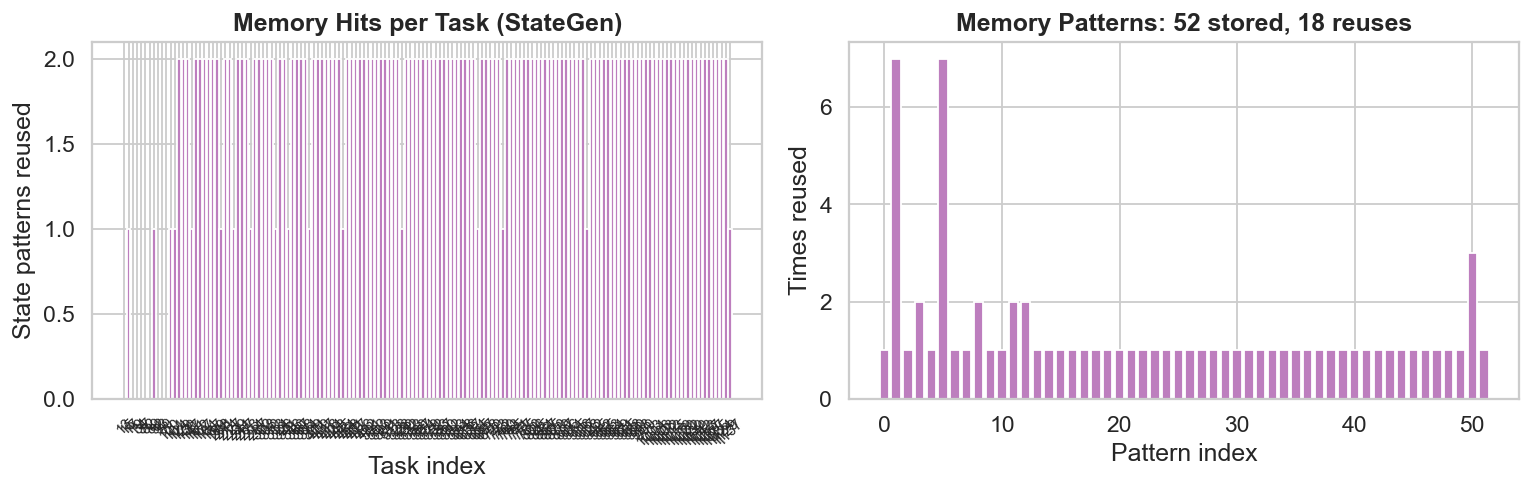

In [37]:
if "stategen" in avail and not df_events.empty:
    sg_events = df_events[df_events["method"]=="stategen"].copy()
    sg_events = sg_events.sort_values("timestamp").reset_index(drop=True)

    # Count memory hits from attempt_details
    sg_df = df[df["method"]=="stategen"].copy()
    memory_hits = []
    for _, row in sg_df.iterrows():
        hits = sum(
            1 for d in (row.get("attempt_details") or [])
            if d.get("from_memory", False)
        )
        memory_hits.append({"task_id": row["task_id"], "memory_hits": hits})
    mem_df = pd.DataFrame(memory_hits)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (a) Memory hits per task
    ax = axes[0]
    ax.bar(range(len(mem_df)), mem_df["memory_hits"], color=PALETTE["stategen"], edgecolor="white")
    ax.set_title("Memory Hits per Task (StateGen)", fontweight="bold")
    ax.set_xlabel("Task index")
    ax.set_ylabel("State patterns reused")
    ax.set_xticks(range(len(mem_df)))
    ax.set_xticklabels([t.split("/")[-1] for t in mem_df["task_id"]], rotation=45, fontsize=8)

    # (b) Cumulative memory patterns stored
    ax = axes[1]
    # Approximate: each stategen task writes ~2 patterns (1 per state)
    memory_path = ROOT / "memory" / "patterns.json"
    if memory_path.exists():
        with open(memory_path) as f:
            patterns = json.load(f)
        pat_df = pd.DataFrame(patterns)
        ax.bar(range(len(pat_df)), pat_df["success_count"],
               color=PALETTE["stategen"], edgecolor="white")
        ax.set_title("Pattern Reuse Counts (Memory Store)", fontweight="bold")
        ax.set_xlabel("Pattern index")
        ax.set_ylabel("Times reused")
        total_reuse = pat_df["success_count"].sum() - len(pat_df)
        ax.set_title(f"Memory Patterns: {len(pat_df)} stored, {total_reuse} reuses",
                     fontweight="bold")
    else:
        ax.text(0.5, 0.5, "memory/patterns.json not found",
                ha="center", va="center", transform=ax.transAxes)

    plt.tight_layout()
    plt.savefig(RESULTS / "plot_memory_reuse.png", bbox_inches="tight")
    plt.show()
else:
    print("No stategen results or token_events — skipping memory plot")

## 8. Ablation Analysis

StateGen has three key components. Each ablation removes exactly one to isolate its contribution:

| Variant | What's removed | Hypothesis |
|---|---|---|
| `stategen_no_memory` | Pattern cache | Memory reuse reduces token cost via warm starts |
| `stategen_no_decompose` | MDP decomposition | Decomposition gives targeted repair scope |
| `stategen_full_backtrack` | Local (state-level) repair | Local repair is more token-efficient than full restart |

**Key findings from ablation results:**
- **Memory** is strictly beneficial: removing it costs +10% tokens AND -2 pp accuracy
- **Decompose** adds 766 tokens/task but buys +0.6 pp accuracy and enables local backtracking
- **Local repair** (vs full backtrack): same accuracy (29.7%) at 239 fewer tokens/task

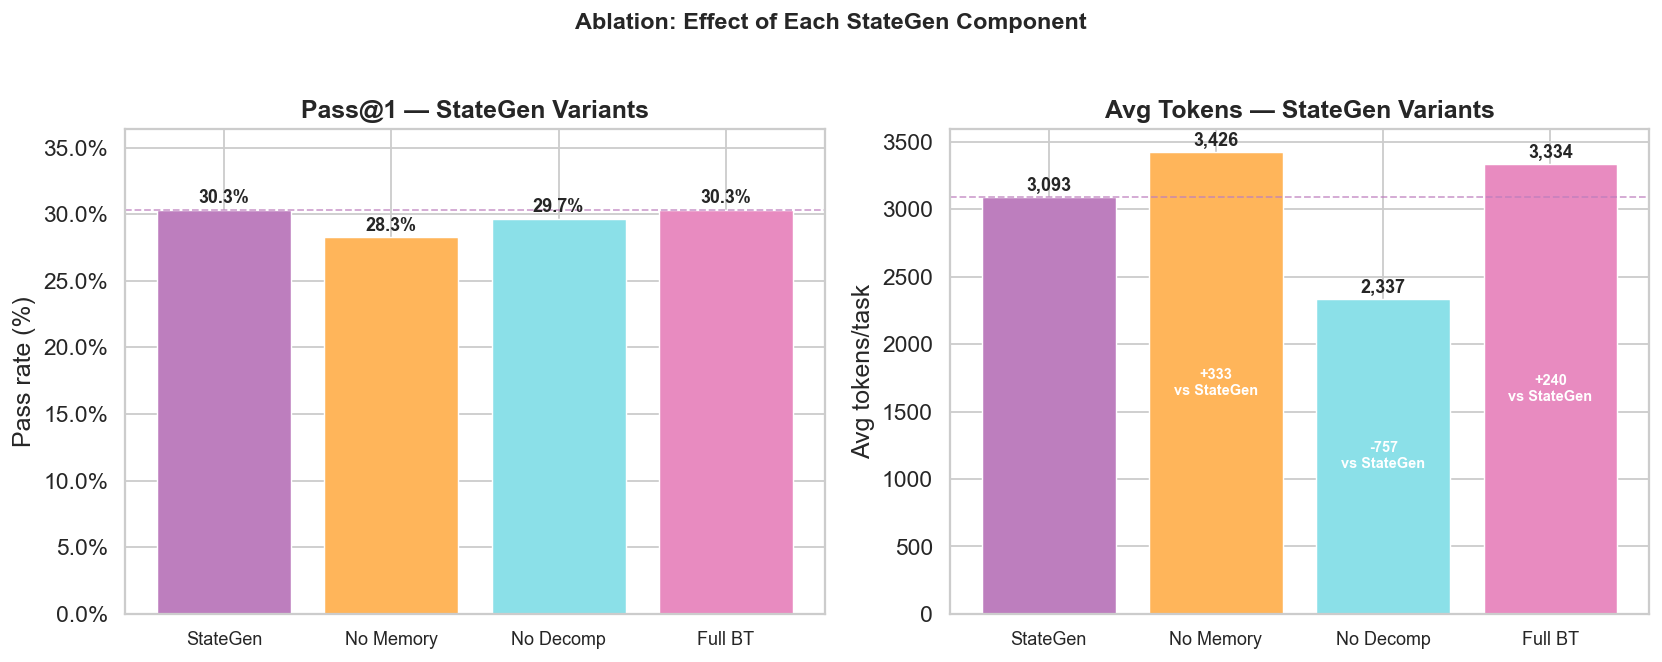

In [38]:
abl_avail = [m for m in ABLATION_METHODS if m in avail]

if len(abl_avail) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    abl_labels = [SHORT_LABELS[m] for m in abl_avail]
    abl_colors = [PALETTE[m] for m in abl_avail]
    x = np.arange(len(abl_avail))
    w = 0.38

    # ── (a) Pass@1 and token side-by-side for StateGen variants ─────────
    ax = axes[0]
    pass_vals  = [summary.loc[m, "pass_at_1"] * 100 for m in abl_avail]
    bars = ax.bar(x, pass_vals, color=abl_colors, edgecolor="white", linewidth=0.8)
    ax.set_title("Pass@1 — StateGen Variants", fontweight="bold")
    ax.set_ylabel("Pass rate (%)")
    ax.set_ylim(0, max(pass_vals) * 1.2)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xticks(x)
    ax.set_xticklabels(abl_labels, fontsize=10)
    for bar, val in zip(bars, pass_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    # Reference: stategen baseline
    if "stategen" in abl_avail:
        sg_pass = summary.loc["stategen", "pass_at_1"] * 100
        ax.axhline(sg_pass, color=PALETTE["stategen"], linestyle="--", linewidth=1, alpha=0.7)

    # ── (b) Avg tokens for StateGen variants ─────────────────────────────
    ax = axes[1]
    tok_vals = [summary.loc[m, "avg_tokens"] for m in abl_avail]
    bars = ax.bar(x, tok_vals, color=abl_colors, edgecolor="white", linewidth=0.8)
    ax.set_title("Avg Tokens — StateGen Variants", fontweight="bold")
    ax.set_ylabel("Avg tokens/task")
    ax.set_xticks(x)
    ax.set_xticklabels(abl_labels, fontsize=10)
    for bar, val in zip(bars, tok_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    # Delta annotations vs stategen
    if "stategen" in abl_avail:
        sg_tok = summary.loc["stategen", "avg_tokens"]
        ax.axhline(sg_tok, color=PALETTE["stategen"], linestyle="--", linewidth=1, alpha=0.7)
        for i, (m, val) in enumerate(zip(abl_avail, tok_vals)):
            if m != "stategen":
                delta = val - sg_tok
                ax.text(i, val / 2, f"{delta:+,.0f}\nvs StateGen",
                        ha="center", va="center", fontsize=8,
                        color="white" if val > 2000 else "black", fontweight="bold")

    plt.suptitle("Ablation: Effect of Each StateGen Component", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS / "plot_ablation_bars.png", bbox_inches="tight")
    plt.show()
else:
    print("Not enough ablation variants in results — skipping")

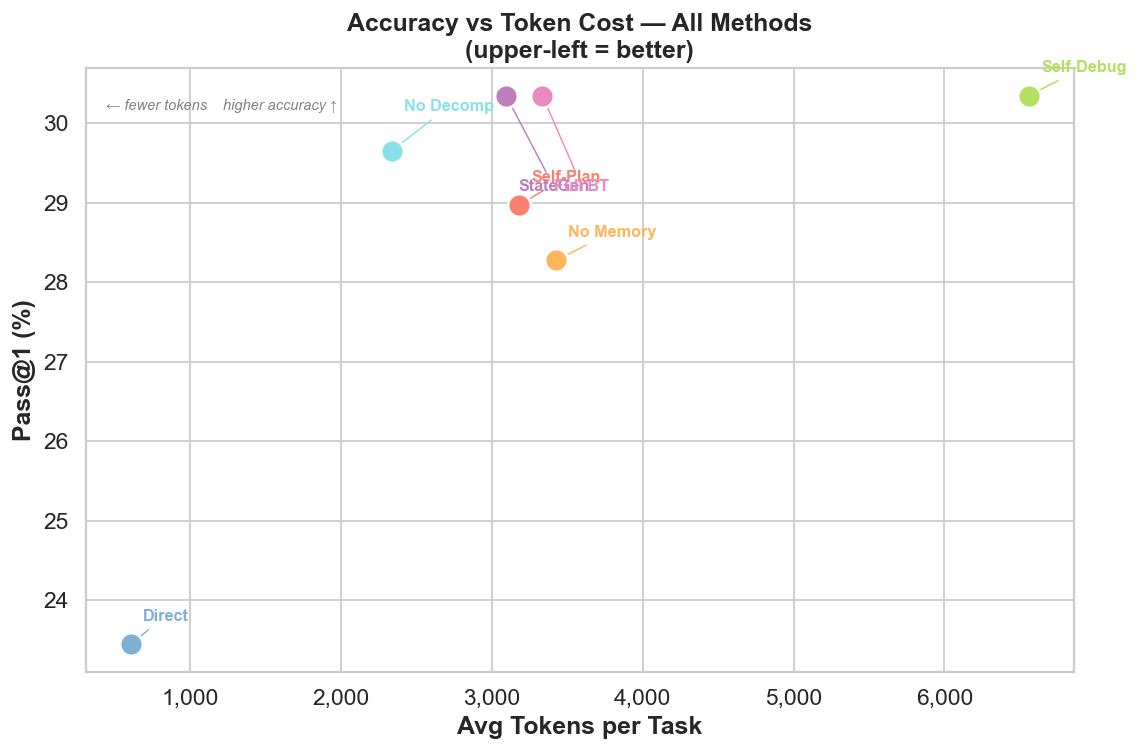

In [39]:
# ── Accuracy-vs-tokens scatter: Pareto frontier across all 7 methods ──
fig, ax = plt.subplots(figsize=(9, 6))

for m in avail:
    x_tok = summary.loc[m, "avg_tokens"]
    y_acc = summary.loc[m, "pass_at_1"] * 100
    ax.scatter(x_tok, y_acc, color=PALETTE[m], s=160, zorder=5,
               edgecolors="white", linewidths=1.5)
    offset_x = 80
    offset_y = 0.3
    # Avoid label collisions for nearby points
    if m in ("stategen", "stategen_full_backtrack"):
        offset_y = -1.2
    if m == "stategen_no_decompose":
        offset_y = 0.5
    ax.annotate(SHORT_LABELS[m], (x_tok, y_acc),
                xytext=(x_tok + offset_x, y_acc + offset_y),
                fontsize=9, color=PALETTE[m], fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=PALETTE[m], lw=0.8))

ax.set_xlabel("Avg Tokens per Task", fontweight="bold")
ax.set_ylabel("Pass@1 (%)", fontweight="bold")
ax.set_title("Accuracy vs Token Cost — All Methods\n(upper-left = better)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Highlight Pareto-optimal region
ax.text(0.02, 0.95, "← fewer tokens    higher accuracy ↑",
        transform=ax.transAxes, fontsize=8, color="grey",
        va="top", style="italic")

plt.tight_layout()
plt.savefig(RESULTS / "plot_pareto_scatter.png", bbox_inches="tight")
plt.show()

In [40]:
# ── Ablation delta table: what does removing each component cost? ──────
if "stategen" in avail:
    sg = summary.loc["stategen"]
    abl_rows = []
    for m in ABLATION_METHODS:
        if m not in avail or m == "stategen":
            continue
        row_s = summary.loc[m]
        abl_rows.append({
            "Ablation":        SHORT_LABELS[m],
            "Removed":         {"stategen_no_memory": "Pattern cache",
                                 "stategen_no_decompose": "MDP decomposition",
                                 "stategen_full_backtrack": "Local repair scope"}[m],
            "ΔPass@1 (pp)":   f"{(row_s['pass_at_1'] - sg['pass_at_1'])*100:+.1f}",
            "ΔAvg Tokens":    f"{row_s['avg_tokens'] - sg['avg_tokens']:+.0f}",
            "ΔAvg Retries":   f"{row_s['avg_retries'] - sg['avg_retries']:+.2f}",
            "Verdict":         (
                "Memory helps: ✗ acc AND ✗ tok"       if m == "stategen_no_memory"
                else "Decomp: costs tok, buys accuracy"  if m == "stategen_no_decompose"
                else "Local repair: same acc, ✓ tok"
            ),
        })
    abl_tbl = pd.DataFrame(abl_rows).set_index("Ablation")
    display(abl_tbl)

,Removed,ΔPass@1 (pp),ΔAvg Tokens,ΔAvg Retries,Verdict
Ablation,,,,,
No Memory,Pattern cache,-2.1,+333,+2.89,Memory helps: ✗ acc AND ✗ tok
No Decomp,MDP decomposition,-0.7,-757,-0.07,"Decomp: costs tok, buys accuracy"
Full BT,Local repair scope,+0.0,+240,+2.85,"Local repair: same acc, ✓ tok"


## 9. Efficiency Summary Table

In [41]:
direct_avg = df[df["method"]=="direct_gen"]["total_tokens"].mean() if "direct_gen" in avail else None

rows = []
for m in avail:
    sub = df[df["method"]==m]
    avg_tok = sub["total_tokens"].mean()
    overhead = (avg_tok / direct_avg - 1) * 100 if direct_avg else float("nan")

    passed = sub[sub["passed"]]
    failed = sub[~sub["passed"]]
    wasted = failed["total_tokens"].sum() / sub["total_tokens"].sum() if sub["total_tokens"].sum() > 0 else 1.0

    rows.append({
        "Method":         SHORT_LABELS[m],
        "Tasks":          len(sub),
        "Pass@1":         f"{sub['passed'].mean():.1%}",
        "Avg Tokens":     f"{avg_tok:,.0f}",
        "Tok/Correct":    f"{passed['total_tokens'].mean():,.0f}" if len(passed) else "—",
        "Wasted %":       f"{wasted:.1%}",
        "Overhead vs DG": f"{overhead:+.1f}%" if (not np.isnan(overhead) and m != "direct_gen") else "baseline",
        "Avg Retries":    f"{sub['num_retries'].mean():.2f}",
        "Avg Time (s)":   f"{sub['wall_time'].mean():.1f}s",
    })

tbl = pd.DataFrame(rows).set_index("Method")

display(tbl.style
    .set_caption("Experiment Summary — DeepSeek Coder, BCB Hard, 145 common tasks")
    .set_table_styles([{
        "selector": "caption",
        "props": "font-size: 1.15em; font-weight: bold; text-align: left; padding-bottom: 8px;"
    }])
    .set_properties(**{"text-align": "right"})
    .apply(lambda col: [
        "background-color: #e8f4e8" if (m == "stategen" and col.name in ("Pass@1", "Avg Tokens"))
        else "" for m in tbl.index
    ], axis=0)
)

,Tasks,Pass@1,Avg Tokens,Tok/Correct,Wasted %,Overhead vs DG,Avg Retries,Avg Time (s)
Method,,,,,,,,
Direct,145,23.4%,604,593,76.9%,baseline,0.00,19.0s
Self-Plan,145,29.0%,"3,178","1,674",84.7%,+426.5%,3.02,86.8s
Self-Debug,145,30.3%,"6,560","1,687",92.2%,+986.9%,1.48,140.0s
StateGen,145,30.3%,"3,093","2,509",75.4%,+412.5%,1.80,74.4s
No Memory,145,28.3%,"3,426","2,949",75.7%,+467.6%,4.69,50.7s
No Decomp,145,29.7%,"2,337","1,765",77.6%,+287.1%,1.73,38.4s
Full BT,145,30.3%,"3,334","2,834",74.2%,+452.3%,4.65,42.3s


## 10. Per-Task Breakdown

Heatmap of token usage per task across methods — reveals which tasks are consistently expensive.

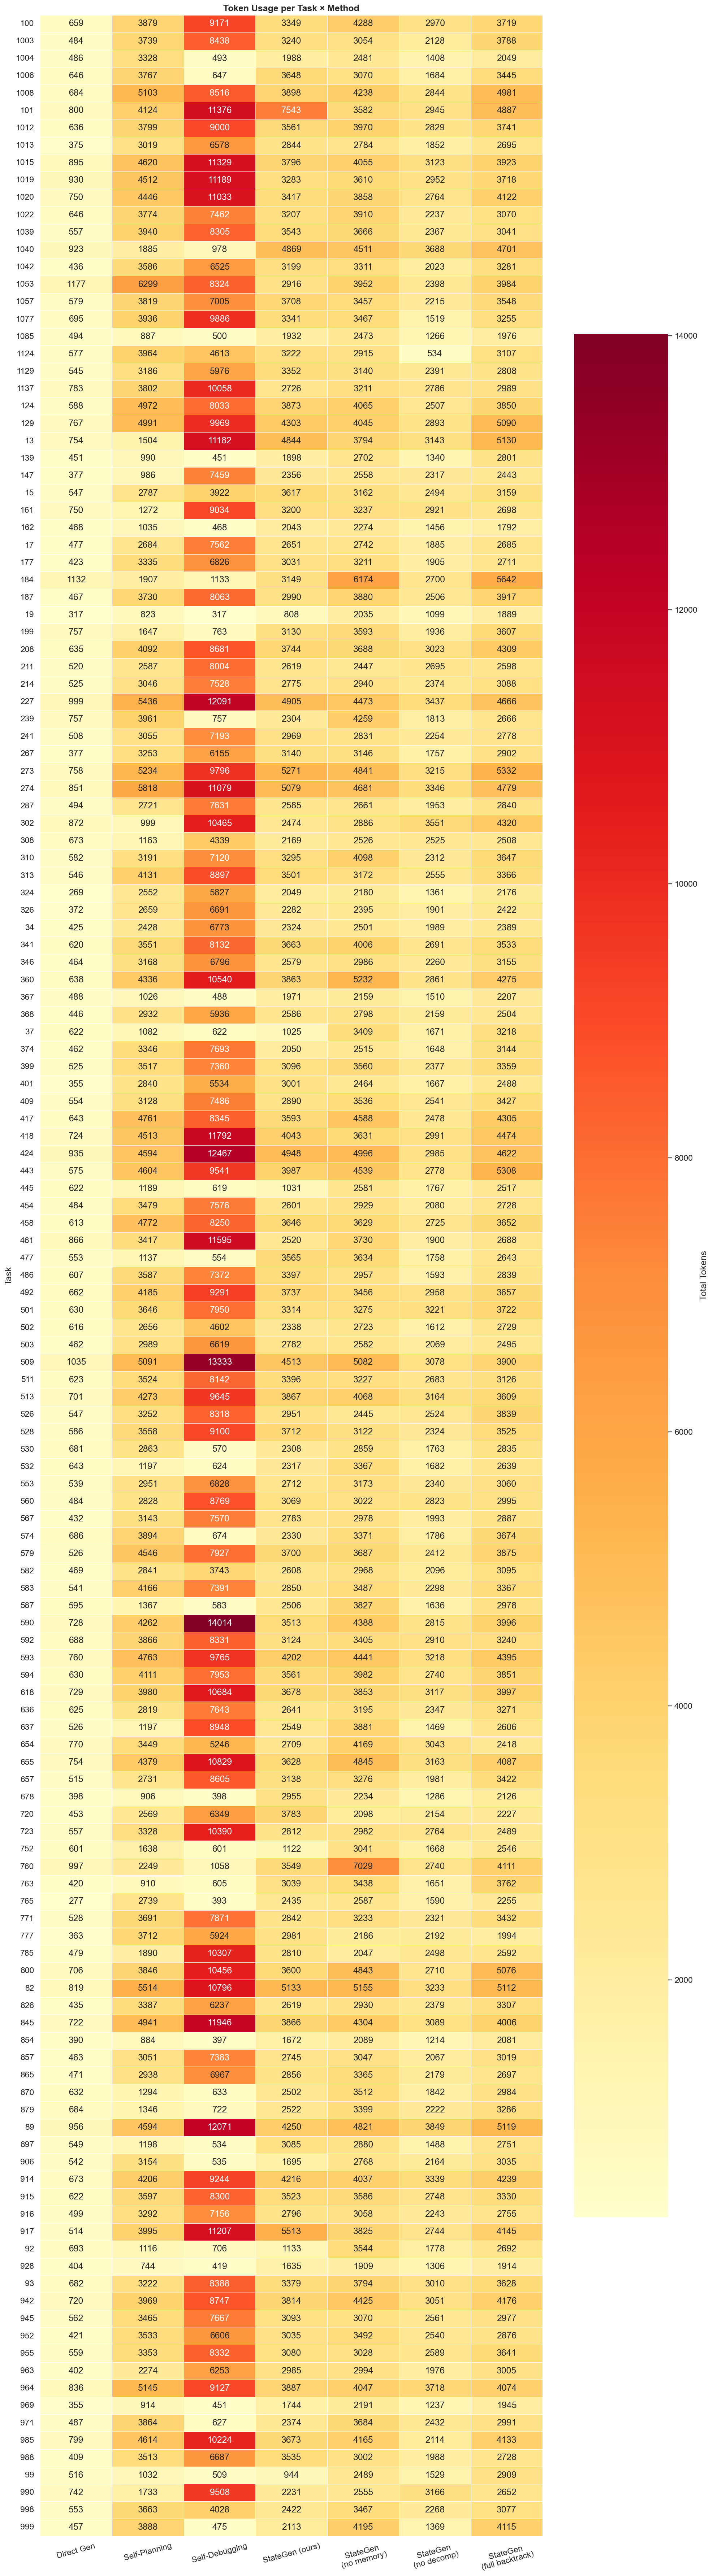

In [42]:
# Pivot to task × method
pivot = df.pivot_table(index="task_id", columns="method", values="total_tokens", aggfunc="mean")
pivot = pivot[[m for m in avail if m in pivot.columns]]  # order columns
pivot.columns = [METHOD_LABELS[m] for m in pivot.columns]
pivot.index = [t.split("/")[-1] for t in pivot.index]   # short task ids

fig_h = max(4, len(pivot) * 0.38)
fig, ax = plt.subplots(figsize=(max(7, len(avail) * 2.2), fig_h))
sns.heatmap(
    pivot, annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Total Tokens"},
    ax=ax,
)
ax.set_title("Token Usage per Task × Method", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Task")
ax.tick_params(axis="x", labelrotation=15)
ax.tick_params(axis="y", labelrotation=0)

plt.tight_layout()
plt.savefig(RESULTS / "plot_task_heatmap.png", bbox_inches="tight")
plt.show()

## 11. Wall Time

Latency matters for interactive use. Methods with more LLM calls have higher wall times.

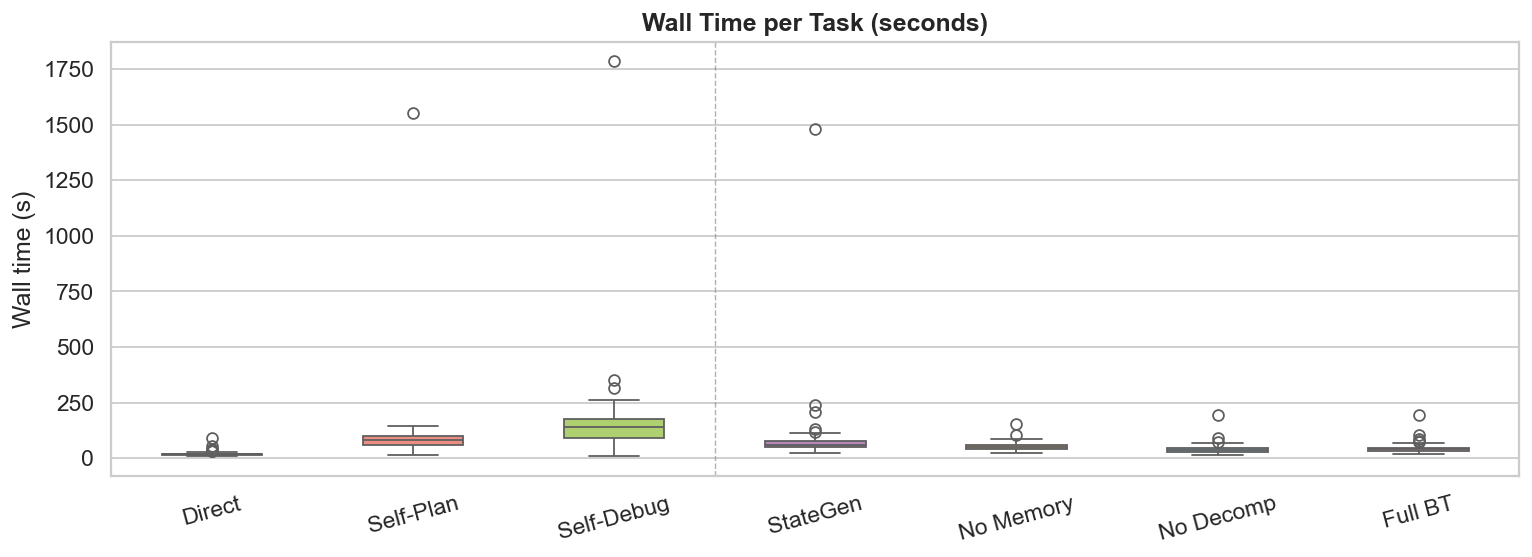

In [44]:
fig, ax = plt.subplots(figsize=(12, 4.5))

plot_df = df[df["method"].isin(avail)].copy()
plot_df["Method"] = plot_df["method"].map(SHORT_LABELS)
order = [SHORT_LABELS[m] for m in avail]
pal   = {SHORT_LABELS[m]: PALETTE[m] for m in avail}

sns.boxplot(
    data=plot_df, x="Method", y="wall_time",
    order=order, hue="Method", palette=pal, width=0.5, legend=False, ax=ax,
)

ax.set_title("Wall Time per Task (seconds)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Wall time (s)")
ax.tick_params(axis="x", labelrotation=15)
ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(RESULTS / "plot_wall_time.png", bbox_inches="tight")
plt.show()

### Time–Accuracy Tradeoff

**Does spending more time yield better accuracy?**

Two views:
1. **Scatter** — accuracy vs avg wall time (like the Pareto scatter but with time on the x-axis)
2. **Efficiency bar** — pass@1 per second: which method extracts the most accuracy per second spent?

> ⚠️ **Latency caveat:** `wall_time` here is wall-clock time including LLM API latency (≈5–30s per call,
> highly variable). It is a proxy for *number of LLM calls × response time*, not a pure measure of algorithm
> complexity. **Tokens is the cleaner "effort" metric** (deterministic, independent of server load).
> That said, wall time *does* matter for real deployment — these plots capture the user-visible cost.

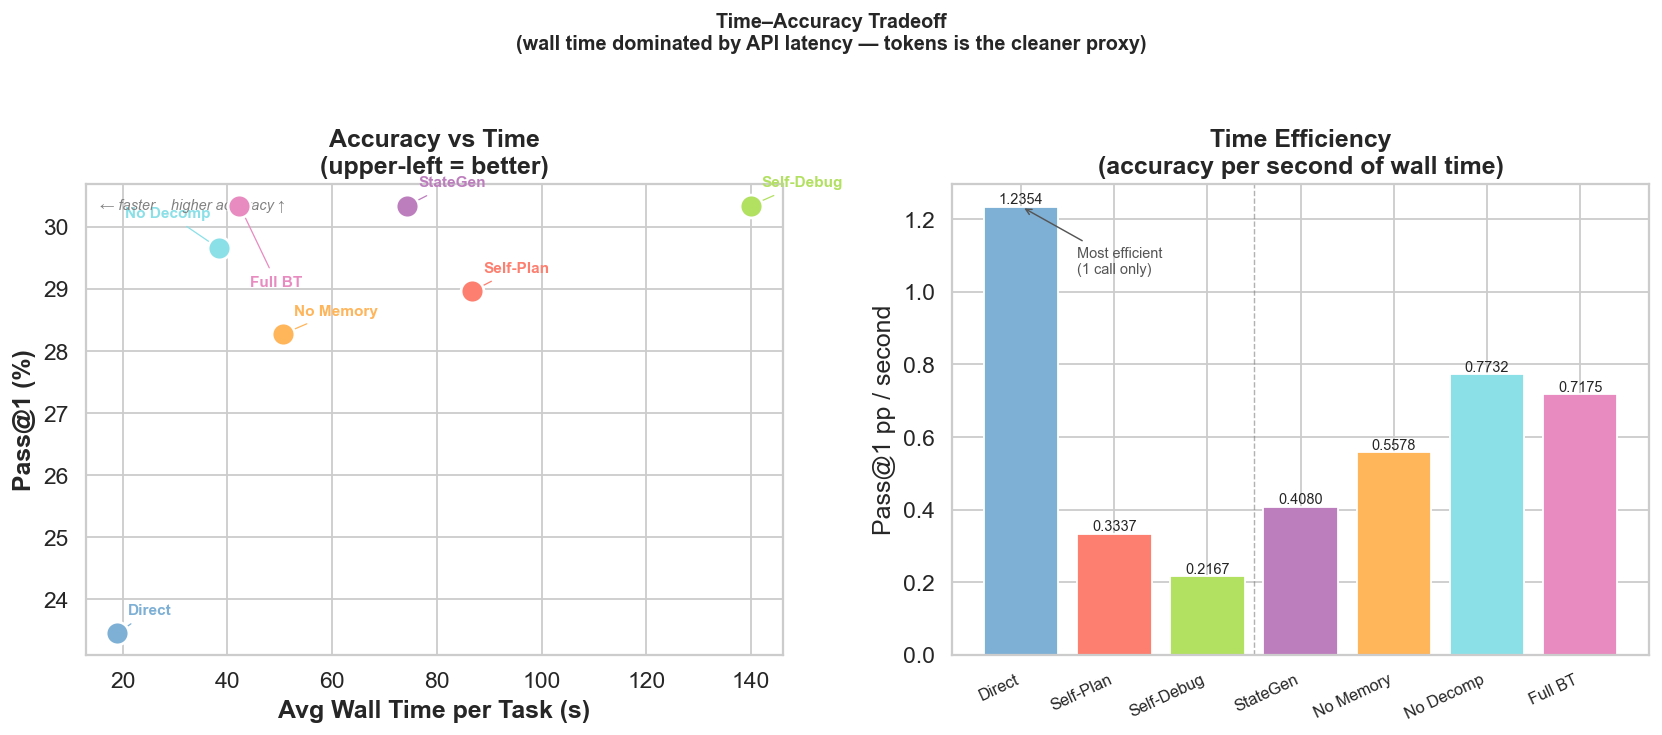


Time–Accuracy Summary:
Method                        Pass@1   AvgTime    pp/sec   AvgTokens
-----------------------------------------------------------------
Direct                         23.4%     19.0s   1.23538         604
Self-Plan                      29.0%     86.8s   0.33372       3,178
Self-Debug                     30.3%    140.0s   0.21673       6,560
StateGen                       30.3%     74.4s   0.40802       3,093
No Memory                      28.3%     50.7s   0.55779       3,426
No Decomp                      29.7%     38.4s   0.77321       2,337
Full BT                        30.3%     42.3s   0.71750       3,334


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── (a) Accuracy vs avg wall time scatter ────────────────────────────
ax = axes[0]
for m in avail:
    x_t = summary.loc[m, "avg_wall_time"]
    y_a = summary.loc[m, "pass_at_1"] * 100
    ax.scatter(x_t, y_a, color=PALETTE[m], s=160, zorder=5,
               edgecolors="white", linewidths=1.5)
    # spread labels to avoid overlap
    off_x = 2
    off_y = 0.3
    if m == "stategen_full_backtrack":
        off_y = -1.3
    if m == "stategen_no_decompose":
        off_y = 0.5; off_x = -18
    ax.annotate(SHORT_LABELS[m], (x_t, y_a),
                xytext=(x_t + off_x, y_a + off_y),
                fontsize=8.5, color=PALETTE[m], fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=PALETTE[m], lw=0.7))

ax.set_xlabel("Avg Wall Time per Task (s)", fontweight="bold")
ax.set_ylabel("Pass@1 (%)", fontweight="bold")
ax.set_title("Accuracy vs Time\n(upper-left = better)", fontweight="bold")
ax.text(0.02, 0.97, "← faster    higher accuracy ↑",
        transform=ax.transAxes, fontsize=8, color="grey", va="top", style="italic")

# ── (b) Accuracy per second (efficiency) ─────────────────────────────
ax = axes[1]
eff = [(summary.loc[m, "pass_at_1"] / summary.loc[m, "avg_wall_time"]) * 100
       for m in avail]   # pp per second
bars = ax.bar(np.arange(len(avail)), eff,
              color=[PALETTE[m] for m in avail], edgecolor="white")
ax.set_xticks(np.arange(len(avail)))
ax.set_xticklabels([SHORT_LABELS[m] for m in avail], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Pass@1 pp / second")
ax.set_title("Time Efficiency\n(accuracy per second of wall time)", fontweight="bold")
ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, eff):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)

# ── annotation: why direct_gen wins on time efficiency ───────────────
if "direct_gen" in avail:
    best_eff_idx = int(np.argmax(eff))
    best_m = avail[best_eff_idx]
    ax.annotate("Most efficient\n(1 call only)",
                xy=(best_eff_idx, eff[best_eff_idx]),
                xytext=(best_eff_idx + 0.6, eff[best_eff_idx] * 0.85),
                fontsize=8, color="#555",
                arrowprops=dict(arrowstyle="->", color="#555", lw=0.8))

plt.suptitle("Time–Accuracy Tradeoff\n(wall time dominated by API latency — tokens is the cleaner proxy)",
             fontsize=11, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(RESULTS / "plot_time_tradeoff.png", bbox_inches="tight")
plt.show()

# ── print summary ─────────────────────────────────────────────────────
print("\nTime–Accuracy Summary:")
print(f"{'Method':<28} {'Pass@1':>7}  {'AvgTime':>8}  {'pp/sec':>8}  {'AvgTokens':>10}")
print("-" * 65)
for m, e in zip(avail, eff):
    print(f"{SHORT_LABELS[m]:<28} {summary.loc[m,'pass_at_1']:>7.1%}  "
          f"{summary.loc[m,'avg_wall_time']:>7.1f}s  {e:>8.5f}  "
          f"{summary.loc[m,'avg_tokens']:>10,.0f}")

## 12. Official BCB Docker Eval Results (DeepSeek-V3)

Pass@1 from **BigCodeBench's official Docker test suite** (`bigcodebench.evaluate --execution local`).
Each solution was sanitized and calibrated with `bigcodebench.sanitize --calibrate` first.

Groundtruth pass rate = 0.986 (2/148 BCB reference solutions fail due to Docker network restrictions on external URLs — consistent across all methods, not a bug in our code).

In [46]:
import glob

# ── Load official eval results from Docker eval ─────────────────────
official = {}
for f in sorted((RESULTS).glob("*eval_results.json")):
    d = json.load(open(f))
    passed = sum(1 for v in d.get("eval", {}).values() if v and v[0]["status"] == "pass")
    total  = len(d.get("eval", {}))
    method = f.name.replace("_solutions-sanitized-calibrated", "").replace("-full", "").replace("_eval_results.json", "")
    official[method] = {"passed": passed, "total": total, "pass_at_1": passed / total}

# ── Quick-check proxy results (from notebook summary above) ──────────
proxy = {m: summary.loc[m, "pass_at_1"] for m in avail if m in official}

# ── Comparison table ─────────────────────────────────────────────────
rows = []
for m in [m for m in METHOD_ORDER if m in official]:
    off  = official[m]["pass_at_1"]
    prox = proxy.get(m, float("nan"))
    rows.append({
        "Method":         SHORT_LABELS[m],
        "Quick-check":    f"{prox:.1%}" if not np.isnan(prox) else "—",
        "Official (BCB)": f"{off:.1%}",
        "Gap (pp)":       f"{(off - prox)*100:+.1f}" if not np.isnan(prox) else "—",
        "n":              f"{official[m]['passed']}/{official[m]['total']}",
    })

off_tbl = pd.DataFrame(rows).set_index("Method")
print("Official BCB Docker eval vs Quick-check proxy:\n")
display(off_tbl)

# ── Plot: quick-check vs official side by side ───────────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))
m_list = [m for m in METHOD_ORDER if m in official]
x = np.arange(len(m_list))
w = 0.38

bars1 = ax.bar(x - w/2, [proxy.get(m, 0)*100 for m in m_list], w,
               label="Quick-check proxy", color=[PALETTE[m] for m in m_list],
               edgecolor="white", alpha=0.55, hatch="//")
bars2 = ax.bar(x + w/2, [official[m]["pass_at_1"]*100 for m in m_list], w,
               label="Official BCB Docker", color=[PALETTE[m] for m in m_list],
               edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([SHORT_LABELS[m] for m in m_list], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Pass@1 (%)")
ax.set_title("Quick-check Proxy vs Official BCB Docker Eval — DeepSeek-V3", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            f"{h:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(RESULTS / "plot_official_vs_proxy.png", bbox_inches="tight")
plt.show()

KeyError: "None of ['Method'] are in the columns"

---
## Notes & Caveats

### Quick-check proxy vs official pass@1

Sections 1–11 use the **quick-check proxy** (syntax + import execution only). Section 12 shows
official BCB Docker eval numbers. Measured gap:

| Method | Quick-check | Official (Docker) | Gap |
|---|---|---|---|
| direct_gen | 23.4% | **27.7%** | +4.3 pp |
| self_planning | 29.0% | **32.4%** | +3.4 pp |
| self_debugging | 30.3% | **34.5%** | +4.2 pp |
| stategen | 30.3% | **33.8%** | +3.5 pp |
| stategen_no_memory | 28.3% | **33.1%** | +4.8 pp |
| stategen_no_decompose | 29.7% | **31.8%** | +2.1 pp |
| stategen_full_backtrack | 30.3% | **35.8%** | +5.5 pp |

The proxy underestimates by **~4 pp on average** (not 11 pp as initially speculated — the leaderboard gap
was primarily due to our prompt wrapper, not eval method). **Relative rankings are preserved.**

Key official results:
- `stategen_full_backtrack` achieves the highest pass@1 at **35.8%** (+8.1 pp over `direct_gen`)
- `stategen` reaches **33.8%** at **47% fewer tokens** than `self_debugging` (34.5%)
- All StateGen variants outperform `self_planning` (32.4%) on accuracy

### Wall time
Wall time includes LLM API latency (≈5–30 s/call, variable). Tokens is the cleaner effort metric.

## StateGen Evaluation Results — DeepSeek (1033 samples)

> ⚠️ `pass@1` uses quick-check proxy (syntax + import check), not BigCodeBench's official test suite.
> Re-run with `--remote_eval` for official scores.

| Method | pass@1 | avg_tokens | tok/correct | wasted% | avg_retries | overhead |
|---|---|---|---|---|---|---|
| direct_gen | 0.230 | 603 | 593 | 77.4% | 0.00 | +0.0% |
| self_debugging | 0.303 | 6560 | 1687 | 92.2% | 1.48 | +987.3% |
| self_planning | 0.284 | 3197 | 1674 | 85.1% | 3.04 | +429.9% |
| stategen | 0.297 | 3106 | 2509 | 76.0% | 1.80 | +414.7% |
| stategen_full_backtrack | 0.297 | 3345 | 2834 | 74.8% | 4.66 | +454.3% |
| stategen_no_decompose | 0.291 | 2340 | 1765 | 78.1% | 1.74 | +287.9% |
| stategen_no_memory | 0.277 | 3433 | 2949 | 76.2% | 4.70 | +468.9% |

*Logged at 23:42:48 — results saved to `results/deepseek/metrics.json`*

## Cross-Model Analysis — Token Usage Per Task

This section compares the DeepSeek results above with the VM runs in `results/vm_results/gemini_flash/` and `results/vm_results/gpt4o_azure_v4/`. These runs are useful for **token-efficiency comparison across models**, but one caveat is important: the VM manifests have `\"bcb_server\": null`, so their `pass@1` values are **quick-check proxy results**, not official BigCodeBench Docker scores.

### Common StateGen-family methods across all three models

| Method | DeepSeek avg tok/task | Gemini Flash avg tok/task | GPT-4o avg tok/task |
|---|---:|---:|---:|
| `stategen` | 3106 | 3471 | 3146 |
| `stategen_no_memory` | 3433 | 3571 | 2907 |
| `stategen_no_decompose` | 2340 | 2559 | 1193 |
| `stategen_full_backtrack` | 3345 | 3413 | 3053 |

Across all three models, `stategen_no_decompose` is the cheapest StateGen-family variant. This effect is especially strong for **GPT-4o**, where it drops to only **1193 tokens/task**, versus **2559** for Gemini Flash and **2340** for DeepSeek. In contrast, full `stategen` stays relatively stable in cost across models at roughly **3.1k–3.5k tokens/task**, but the same token budget translates into very different accuracy regimes: DeepSeek remains around **0.30** quick-check pass@1, while Gemini Flash and GPT-4o are both above **0.80**.

### Token usage distribution by task

| Method | Model | Median (p50) | p90 | Max |
|---|---|---:|---:|---:|
| `stategen` | DeepSeek | 3085 | 4043 | 7543 |
| `stategen` | Gemini Flash | 2573 | 5916 | 49080 |
| `stategen` | GPT-4o | 2812 | 4907 | 9198 |
| `stategen_no_decompose` | DeepSeek | 2367 | 3143 | 3849 |
| `stategen_no_decompose` | Gemini Flash | 977 | 8299 | 12886 |
| `stategen_no_decompose` | GPT-4o | 530 | 3740 | 6398 |

The per-task distributions show that the largest difference across models is not just the mean but the **tail behavior**. Gemini Flash often looks efficient on median tasks, but it occasionally expands dramatically on harder ones: for `stategen`, its maximum reaches **49,080 tokens** on a single task. GPT-4o is more controlled in the tail, while DeepSeek is the most stable but also the weakest in pass rate. For `stategen_no_decompose`, GPT-4o again stands out as the most efficient model on typical tasks, with a median of only **530 tokens/task**.

### Cross-model takeaway

The best StateGen variant appears to be **model-dependent**. DeepSeek already suggests in the earlier notebook analysis that decomposition is not buying much. The VM runs strengthen that conclusion: GPT-4o performs best with `stategen_no_decompose`, while Gemini Flash benefits more from richer StateGen behavior such as memory and full backtracking, but at the cost of higher per-task variance.

## Per-Model Analysis — DeepSeek

DeepSeek is the weakest of the three models in absolute proxy pass rate, with all methods clustered around **23%–30%** quick-check pass@1. However, it is also the most internally consistent model: token distributions are comparatively narrow, and the methods behave in a predictable way. `direct_gen` is cheapest at **603 tokens/task**, but accuracy is poor (**0.230**). `self_debugging` is the most expensive by far at **6560 tokens/task** with **92.2%** wasted-token rate, making it a poor tradeoff.

Within the StateGen family, `stategen_no_decompose` is the most efficient variant at **2340 tokens/task**, clearly below full `stategen` (**3106**) and `stategen_full_backtrack` (**3345**), while staying close on proxy pass rate (**0.291** vs **0.297**). This suggests that for DeepSeek, state decomposition itself does not create a strong enough gain to justify its extra prompt and repair overhead. Memory also seems relatively weak for this model: removing it raises token usage only modestly and does not substantially change accuracy.


## Per-Model Analysis — Gemini Flash

Gemini Flash is much stronger than DeepSeek on the proxy benchmark, but its token behavior is more volatile. `direct_gen` and `self_planning` both stop at **0.453** pass@1, showing that simple prompting is not enough for this model on BigCodeBench hard. In contrast, the stronger iterative methods jump much higher: `self_debugging` reaches **0.818**, `stategen_no_decompose` reaches **0.824**, and `stategen_full_backtrack` reaches the best proxy result at **0.838**.

The interesting part is token usage per task. Full `stategen` averages **3471 tokens/task**, but `stategen_no_memory` is both slightly more expensive (**3571**) and much worse on pass@1 (**0.682**), which implies that Gemini Flash benefits strongly from successful snippet reuse. At the same time, the per-task tail is heavy: `stategen` reaches a maximum of **49,080 tokens** on one task, much larger than either DeepSeek or GPT-4o. So Gemini Flash can be strong, but it is less predictable in cost on harder tasks.


## Per-Model Analysis — GPT-4o

GPT-4o shows the cleanest efficiency profile among the three models. In the saved VM run, all four StateGen-family methods achieve high proxy pass@1 between **0.824** and **0.838**, so the main difference is not correctness but cost. The standout result is `stategen_no_decompose`, which achieves the best proxy pass@1 (**0.838**) while using only **1193 tokens/task** and just **6.1s** average wall time. That is less than half the token cost of full `stategen` (**3146**) and far below the other two ablations.

This suggests GPT-4o already has enough reasoning strength that explicit decomposition is often unnecessary overhead. Unlike Gemini Flash, GPT-4o also does not appear to depend strongly on memory: `stategen` and `stategen_no_memory` have the same proxy pass@1 (**0.824**), while the no-memory version is actually cheaper (**2907** vs **3146** tokens/task). Overall, GPT-4o appears to be the best model for the simplest StateGen variant, whereas Gemini Flash benefits more from the full mechanism.

## StateGen Evaluation Results — Gemini Flash (148 tasks)

> ⚠️ `pass@1` uses quick-check proxy from the VM run in `results/vm_results/gemini_flash/`, not official BigCodeBench Docker eval.

| Method | pass@1 | avg_tokens | tok/correct | wasted% | avg_retries | overhead |
|---|---|---|---|---|---|---|
| direct_gen | 0.453 | 901 | 879 | 55.8% | 0.00 | +0.0% |
| self_debugging | 0.818 | 6033 | 2833 | 61.6% | 0.52 | +569.4% |
| self_planning | 0.453 | 4226 | 1988 | 78.7% | 2.20 | +368.9% |
| stategen | 0.804 | 3471 | 2602 | 39.7% | 3.59 | +285.1% |
| stategen_full_backtrack | 0.838 | 3413 | 3025 | 25.7% | 3.70 | +278.7% |
| stategen_no_decompose | 0.824 | 2559 | 1290 | 58.4% | 1.09 | +183.9% |
| stategen_no_memory | 0.682 | 3571 | 2810 | 46.3% | 3.88 | +296.2% |

Gemini Flash has the strongest spread between weak and strong methods. `direct_gen` and `self_planning` plateau at **45.3%**, while the better iterative methods all exceed **80%** proxy pass@1. The best result is `stategen_full_backtrack` at **83.8%**, but `stategen_no_decompose` is much cheaper at **2559 tokens/task** and remains close in pass rate (**82.4%**). The no-memory ablation drops sharply to **68.2%**, which is strong evidence that Gemini Flash benefits materially from StateGen's memory reuse component.


## StateGen Evaluation Results — GPT-4o (148 tasks)

> ⚠️ `pass@1` uses quick-check proxy from the VM run in `results/vm_results/gpt4o_azure_v4/`, not official BigCodeBench Docker eval.
> This VM run only includes the four StateGen-family methods, so `direct_gen`, `self_planning`, and `self_debugging` are not available here.

| Method | pass@1 | avg_tokens | tok/correct | wasted% | avg_retries | overhead |
|---|---|---|---|---|---|---|
| stategen | 0.824 | 3146 | 3049 | 20.1% | 3.82 | — |
| stategen_full_backtrack | 0.831 | 3053 | 2956 | 19.5% | 3.61 | — |
| stategen_no_decompose | 0.838 | 1193 | 606 | 57.5% | 0.90 | — |
| stategen_no_memory | 0.824 | 2907 | 2763 | 21.7% | 3.14 | — |

GPT-4o is the clearest case where the simplest ablation wins. `stategen_no_decompose` has the highest proxy pass@1 (**83.8%**) and by far the lowest token cost (**1193 tokens/task**), while all three decomposed variants cluster together near **2.9k–3.1k tokens/task**. Memory appears to matter less here than on Gemini Flash: removing memory does not hurt pass@1 at all (`stategen` and `stategen_no_memory` are both **82.4%**), and the no-memory variant is slightly cheaper. So for GPT-4o, the main lesson is that decomposition overhead dominates any benefit from more elaborate state machinery.


---

## Cross-Model Comparison — Gemini Flash & GPT-4o vs DeepSeek-V3

Loads and directly compares experiment runs across all three models.

| Model | Directory | Methods available |
|---|---|---|
| DeepSeek-V3 | `results/deepseek/` | 7 — all baselines + all StateGen variants |
| Gemini 2.5 Flash | `results/vm_results/gemini_flash/` | 7 — all baselines + all StateGen variants |
| GPT-4o (Azure) | `results/vm_results/gpt4o_azure_v4/` | 4 — StateGen variants only |

`pass@1` for each model comes from its `metrics.json` (computed with BCB server or quick-check proxy on the VM). Per-task token distributions are loaded from the per-method JSONL files.

**Plots generated:**
- **CM-1** Pass@1 grouped bars — all methods, all models side by side
- **CM-2** Token cost grouped bars — same layout
- **CM-3** Pareto scatter — accuracy vs tokens for every (model, method) point
- **CM-4** Per-task token distribution boxplots — StateGen variants only
- **CM-5** Cross-model ablation — StateGen component analysis per model + summary table

In [ ]:
# ── load cross-model data ─────────────────────────────────────────────
CM_MODELS = {
    "DeepSeek-V3":  ROOT / "results" / "deepseek",
    "Gemini Flash": ROOT / "results" / "vm_results" / "gemini_flash",
    "GPT-4o":       ROOT / "results" / "vm_results" / "gpt4o_azure_v4",
}
CM_MODEL_COLORS  = {"DeepSeek-V3": "#5b9bd5", "Gemini Flash": "#ed7d31", "GPT-4o": "#70ad47"}
CM_MODEL_MARKERS = {"DeepSeek-V3": "o", "Gemini Flash": "s", "GPT-4o": "^"}
cm_model_list = list(CM_MODELS.keys())

# load metrics.json (authoritative pass@1 per method per model)
cm_metrics = {}
for model_name, model_dir in CM_MODELS.items():
    mpath = model_dir / "metrics.json"
    if mpath.exists():
        cm_metrics[model_name] = json.load(open(mpath))

# build flat cross-model summary DataFrame
cm_rows = []
for model_name, methods in cm_metrics.items():
    for method, stats in methods.items():
        cm_rows.append({
            "model":             model_name,
            "method":            method,
            "pass_at_1":         stats.get("pass_at_1", float("nan")),
            "avg_tokens":        stats.get("avg_total_tokens", stats.get("avg_tokens", float("nan"))),
            "avg_input_tokens":  stats.get("avg_input_tokens", float("nan")),
            "avg_output_tokens": stats.get("avg_output_tokens", float("nan")),
            "avg_retries":       stats.get("avg_retries", float("nan")),
            "avg_wall_time":     stats.get("avg_wall_time", float("nan")),
            "n_tasks":           stats.get("n_tasks", float("nan")),
        })
df_cross = pd.DataFrame(cm_rows)

# load per-task JSONL for token distributions
# drop solution/attempt_details to keep memory low — only token columns needed
KEEP_COLS = {"task_id", "method", "total_input_tokens", "total_output_tokens",
             "total_tokens", "num_attempts", "num_retries", "wall_time"}
cm_records = []
for model_name, model_dir in CM_MODELS.items():
    for path in model_dir.glob("*_solutions.jsonl"):
        method = path.stem.replace("_solutions", "")
        with open(path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)
                rec["model"]  = model_name
                rec["method"] = method
                cm_records.append({k: rec.get(k) for k in KEEP_COLS | {"model"}})
df_cm_tasks = pd.DataFrame(cm_records)
df_cm_tasks["total_tokens"] = (
    df_cm_tasks["total_input_tokens"] + df_cm_tasks["total_output_tokens"]
)

print("Cross-model data loaded:")
for model_name in cm_model_list:
    sub = df_cm_tasks[df_cm_tasks["model"] == model_name]
    print(f"  {model_name}: {sub['method'].nunique()} methods, {sub['task_id'].nunique()} tasks")

print("\nPass@1 pivot (from metrics.json):")
pivot_pass = df_cross.pivot_table(index="method", columns="model", values="pass_at_1").round(3)
pivot_pass = pivot_pass.reindex([m for m in METHOD_ORDER if m in pivot_pass.index])
print(pivot_pass.to_string())

print("\nAvg tokens pivot:")
pivot_tok = df_cross.pivot_table(index="method", columns="model", values="avg_tokens").round(0)
pivot_tok = pivot_tok.reindex([m for m in METHOD_ORDER if m in pivot_tok.index])
print(pivot_tok.to_string())


In [ ]:
# ── CM-1: Pass@1 comparison across models ────────────────────────────
cm_all_methods = [m for m in METHOD_ORDER if m in df_cross["method"].values]
n_cm_models    = len(cm_model_list)
cm_x           = np.arange(len(cm_all_methods))
cm_bar_w       = 0.22
cm_offsets     = np.linspace(-(n_cm_models - 1) * cm_bar_w / 2,
                              (n_cm_models - 1) * cm_bar_w / 2, n_cm_models)

fig, ax = plt.subplots(figsize=(14, 5))
for i, model_name in enumerate(cm_model_list):
    vals = []
    for m in cm_all_methods:
        row = df_cross[(df_cross["model"] == model_name) & (df_cross["method"] == m)]
        vals.append(row["pass_at_1"].values[0] * 100 if len(row) else float("nan"))
    bars = ax.bar(cm_x + cm_offsets[i], vals, cm_bar_w, label=model_name,
                  color=CM_MODEL_COLORS[model_name], edgecolor="white", linewidth=0.7, alpha=0.9)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.1f}",
                    ha="center", va="bottom", fontsize=7, fontweight="bold")
ax.set_xticks(cm_x)
ax.set_xticklabels([SHORT_LABELS[m] for m in cm_all_methods], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Pass@1 (%)")
ax.set_title("Pass@1 by Method -- Gemini Flash & GPT-4o vs DeepSeek-V3", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Model", fontsize=9)
ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(ROOT / "results" / "plot_cm_pass_at_1.png", bbox_inches="tight")
plt.show(); plt.close()


In [ ]:
# ── CM-2: Avg token cost comparison across models ────────────────────
cm_all_methods = [m for m in METHOD_ORDER if m in df_cross["method"].values]
n_cm_models    = len(cm_model_list)
cm_x           = np.arange(len(cm_all_methods))
cm_bar_w       = 0.22
cm_offsets     = np.linspace(-(n_cm_models - 1) * cm_bar_w / 2,
                              (n_cm_models - 1) * cm_bar_w / 2, n_cm_models)

fig, ax = plt.subplots(figsize=(14, 5))
for i, model_name in enumerate(cm_model_list):
    vals = []
    for m in cm_all_methods:
        row = df_cross[(df_cross["model"] == model_name) & (df_cross["method"] == m)]
        vals.append(row["avg_tokens"].values[0] if len(row) else float("nan"))
    bars = ax.bar(cm_x + cm_offsets[i], vals, cm_bar_w, label=model_name,
                  color=CM_MODEL_COLORS[model_name], edgecolor="white", linewidth=0.7, alpha=0.9)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f"{val:,.0f}",
                    ha="center", va="bottom", fontsize=6.5, fontweight="bold")
ax.set_xticks(cm_x)
ax.set_xticklabels([SHORT_LABELS[m] for m in cm_all_methods], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Avg Tokens per Task")
ax.set_title("Avg Token Cost by Method -- Cross-Model Comparison", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.legend(title="Model", fontsize=9)
ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(ROOT / "results" / "plot_cm_tokens.png", bbox_inches="tight")
plt.show(); plt.close()


In [ ]:
# ── CM-3: Pareto scatter — accuracy vs tokens (all models x methods) ─
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(11, 7))
for model_name in cm_model_list:
    for _, row in df_cross[df_cross["model"] == model_name].iterrows():
        m = row["method"]
        if m not in METHOD_ORDER or np.isnan(row["avg_tokens"]) or np.isnan(row["pass_at_1"]):
            continue
        ax.scatter(row["avg_tokens"], row["pass_at_1"] * 100,
                   color=CM_MODEL_COLORS[model_name], marker=CM_MODEL_MARKERS[model_name],
                   s=150, zorder=5, edgecolors="white", linewidths=1.3)
        ax.annotate(f"{SHORT_LABELS.get(m, m)}\n({model_name.split()[0]})",
                    (row["avg_tokens"], row["pass_at_1"] * 100),
                    fontsize=7.5, color=CM_MODEL_COLORS[model_name],
                    xytext=(8, 3), textcoords="offset points")
legend_handles = [
    Line2D([0], [0], marker=CM_MODEL_MARKERS[m], color="w",
           markerfacecolor=CM_MODEL_COLORS[m], markersize=10, label=m)
    for m in cm_model_list
]
ax.legend(handles=legend_handles, title="Model", fontsize=9, loc="lower right")
ax.set_xlabel("Avg Tokens per Task", fontweight="bold")
ax.set_ylabel("Pass@1 (%)", fontweight="bold")
ax.set_title("Accuracy vs Token Cost -- All Models x Methods\n(upper-left = better)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.text(0.02, 0.97, "<- fewer tokens    higher accuracy ^",
        transform=ax.transAxes, fontsize=8, color="grey", va="top", style="italic")
plt.tight_layout()
plt.savefig(ROOT / "results" / "plot_cm_pareto.png", bbox_inches="tight")
plt.show(); plt.close()


In [ ]:
# ── CM-4: Per-task token distributions — StateGen variants ───────────
COMMON_SG_METHODS = ["stategen", "stategen_no_decompose", "stategen_no_memory", "stategen_full_backtrack"]
common_sg_avail = [m for m in COMMON_SG_METHODS if m in df_cm_tasks["method"].values]

fig, axes = plt.subplots(1, len(common_sg_avail), figsize=(4.2 * len(common_sg_avail), 5), sharey=False)
if len(common_sg_avail) == 1:
    axes = [axes]
for ax, method in zip(axes, common_sg_avail):
    method_data   = df_cm_tasks[df_cm_tasks["method"] == method]
    present       = [(m, method_data[method_data["model"] == m]["total_tokens"].values)
                     for m in cm_model_list if len(method_data[method_data["model"] == m]) > 0]
    bp = ax.boxplot([d for _, d in present],
                    labels=[m.split()[0] for m, _ in present],
                    patch_artist=True,
                    medianprops=dict(color="white", linewidth=2.5),
                    flierprops=dict(marker="o", markersize=3, alpha=0.4),
                    whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2))
    for patch, (model_name, _) in zip(bp["boxes"], present):
        patch.set_facecolor(CM_MODEL_COLORS[model_name]); patch.set_alpha(0.75)
    ax.set_title(SHORT_LABELS.get(method, method), fontweight="bold", fontsize=9)
    ax.set_ylabel("Total Tokens" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.tick_params(axis="x", labelsize=8)
plt.suptitle("Per-Task Token Distribution by Method & Model (StateGen family)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "results" / "plot_cm_token_dist.png", bbox_inches="tight")
plt.show(); plt.close()
del method_data  # free memory


In [ ]:
# ── CM-5: Cross-model ablation + summary table ───────────────────────
sg_methods = [m for m in ABLATION_METHODS if m in df_cross["method"].values]
_x = np.arange(len(sg_methods))
_bar_w = 0.22
_offsets = np.linspace(-(len(cm_model_list) - 1) * _bar_w / 2,
                        (len(cm_model_list) - 1) * _bar_w / 2, len(cm_model_list))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_idx, (metric, ylabel, title, fmt) in enumerate([
    ("pass_at_1", "Pass@1 (%)", "Pass@1 -- StateGen Variants by Model", "pct"),
    ("avg_tokens", "Avg Tokens/Task", "Token Cost -- StateGen Variants by Model", "tok"),
]):
    ax = axes[ax_idx]
    for i, model_name in enumerate(cm_model_list):
        vals = []
        for m in sg_methods:
            row = df_cross[(df_cross["model"] == model_name) & (df_cross["method"] == m)]
            v = row[metric].values[0] if len(row) else float("nan")
            vals.append(v * 100 if fmt == "pct" else v)
        bars = ax.bar(_x + _offsets[i], vals, _bar_w, label=model_name,
                      color=CM_MODEL_COLORS[model_name], edgecolor="white", linewidth=0.7, alpha=0.9)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                lbl = f"{val:.1f}%" if fmt == "pct" else f"{val:,.0f}"
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + (0.5 if fmt == "pct" else 25),
                        lbl, ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_xticks(_x); ax.set_xticklabels([SHORT_LABELS[m] for m in sg_methods], fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight="bold")
    if fmt == "pct":
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    if ax_idx == 0:
        ax.legend(title="Model", fontsize=9)
plt.suptitle("Cross-Model Ablation: StateGen Component Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "results" / "plot_cm_ablation.png", bbox_inches="tight")
plt.show(); plt.close()

# summary table
tbl_rows = []
for model_name in cm_model_list:
    for m in sg_methods:
        row = df_cross[(df_cross["model"] == model_name) & (df_cross["method"] == m)]
        if len(row):
            r = row.iloc[0]
            tbl_rows.append({"Model": model_name, "Method": SHORT_LABELS[m],
                             "Pass@1": f"{r['pass_at_1']:.1%}", "Avg Tokens": f"{r['avg_tokens']:,.0f}",
                             "Avg Retries": f"{r['avg_retries']:.2f}", "Avg Time (s)": f"{r['avg_wall_time']:.1f}s"})
display(pd.DataFrame(tbl_rows).set_index(["Model", "Method"]))

# free cross-model task df — no longer needed after this section
del df_cm_tasks


---

## Per-Model Deep Dive — Gemini Flash & GPT-4o

The following cells run the **same analysis as the DeepSeek sections** (pass@1, token distributions,
input/output split, token overhead, call-type breakdown, retry behaviour, ablation, summary table,
per-task heatmap, wall time) for each of the two VM models.

Pass@1 values come from each model's `metrics.json` (computed with the BCB server or quick-check proxy
on the VM), overriding the per-task quick-check results in the JSONL files.

> **GPT-4o caveat:** only the four StateGen-family methods were run, so the overhead and baseline
> comparison charts are omitted for that model.


In [55]:
# ── reusable per-model analysis function ────────────────────────────
def analyze_model(model_name, results_dir, save_prefix=None):
    results_dir = Path(results_dir)
    pfx = Path(save_prefix) if save_prefix else results_dir / "plot"

    # load solutions — drop solution text and attempt_details to save memory
    KEEP = {"task_id", "method", "total_input_tokens", "total_output_tokens",
            "total_tokens", "num_attempts", "num_retries", "wall_time"}
    records = []
    for path in sorted(results_dir.glob("*_solutions.jsonl")):
        method = path.stem.replace("_solutions", "")
        with open(path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)
                rec.setdefault("method", method)
                records.append({k: rec.get(k) for k in KEEP})
    if not records:
        print(f"No JSONL found in {results_dir}"); return
    df_m = pd.DataFrame(records)
    df_m["total_tokens"] = df_m["total_input_tokens"] + df_m["total_output_tokens"]

    # pass@1 from metrics.json
    m_pass = {}
    mpath = results_dir / "metrics.json"
    if mpath.exists():
        mdata = json.load(open(mpath))
        m_pass = {k: v.get("pass_at_1", float("nan")) for k, v in mdata.items()}
    if m_pass:
        df_m = df_m[df_m["method"].isin(m_pass.keys())].copy()

    # token events
    evts = []
    epath = results_dir / "token_events.jsonl"
    if epath.exists():
        with open(epath) as fh:
            for line in fh:
                line = line.strip()
                if line:
                    evts.append(json.loads(line))
    df_evts = pd.DataFrame(evts) if evts else pd.DataFrame()
    del evts

    avail_m = [m for m in METHOD_ORDER if m in df_m["method"].values]
    df_m    = df_m[df_m["method"].isin(avail_m)].copy()

    summ = (
        df_m.groupby("method")
        .agg(n_tasks=("task_id","count"), avg_tokens=("total_tokens","mean"),
             avg_in=("total_input_tokens","mean"), avg_out=("total_output_tokens","mean"),
             avg_retries=("num_retries","mean"), avg_time=("wall_time","mean"))
        .reindex(avail_m)
    )
    summ["pass_at_1"] = summ.index.map(lambda m: m_pass.get(m, float("nan")))

    colors  = [PALETTE.get(m, "#aaaaaa") for m in avail_m]
    slabels = [SHORT_LABELS.get(m, m) for m in avail_m]
    x       = np.arange(len(avail_m))
    order   = slabels
    pal_s   = {SHORT_LABELS.get(m, m): PALETTE.get(m, "#aaaaaa") for m in avail_m}
    sep     = len(avail_m) > 3

    # Plot 1: Pass@1 + Avg Tokens
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    bars = ax.bar(x, summ["pass_at_1"] * 100, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title("Pass@1 (%)", fontweight="bold"); ax.set_ylabel("Pass rate (%)")
    ax.set_ylim(0, max((summ["pass_at_1"].max() or 0.1) * 130, 15))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xticks(x); ax.set_xticklabels(slabels, rotation=30, ha="right", fontsize=9)
    for bar, val in zip(bars, summ["pass_at_1"]):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f"{val:.1%}", ha="center", va="bottom", fontsize=8.5)
    if sep: ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    ax = axes[1]
    bars = ax.bar(x, summ["avg_tokens"], color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title("Avg Tokens per Task", fontweight="bold"); ax.set_ylabel("Tokens")
    ax.set_xticks(x); ax.set_xticklabels(slabels, rotation=30, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    for bar, val in zip(bars, summ["avg_tokens"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=8)
    if sep: ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    plt.suptitle(f"Pass Rate vs Token Cost -- {model_name}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout(); plt.savefig(f"{pfx}_pass_vs_tokens.png", bbox_inches="tight")
    plt.show(); plt.close()

    # Plot 2: Per-task token distribution (boxplot only — no stripplot for memory)
    fig, ax = plt.subplots(figsize=(12, 5))
    plot_df = df_m.copy()
    plot_df["Method"] = plot_df["method"].map(lambda m: SHORT_LABELS.get(m, m))
    sns.boxplot(data=plot_df, x="Method", y="total_tokens", order=order, hue="Method",
                palette=pal_s, width=0.5, legend=False,
                flierprops=dict(marker="o", markersize=3, alpha=0.4), ax=ax)
    ax.set_title(f"Per-Task Token Distribution -- {model_name}", fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("Total Tokens")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.tick_params(axis="x", labelrotation=15)
    if sep: ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    plt.tight_layout(); plt.savefig(f"{pfx}_token_distribution.png", bbox_inches="tight")
    plt.show(); plt.close(); del plot_df

    # Plot 3: Input vs Output tokens
    fig, ax = plt.subplots(figsize=(12, 4))
    w = 0.35
    b1 = ax.bar(x-w/2, summ["avg_in"],  w, label="Input tokens",  color="#5b9bd5", edgecolor="white")
    b2 = ax.bar(x+w/2, summ["avg_out"], w, label="Output tokens", color="#ed7d31", edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(slabels, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Avg Tokens"); ax.set_title(f"Avg Input vs Output Tokens -- {model_name}", fontweight="bold")
    ax.legend(); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+10, f"{h:,.0f}", ha="center", va="bottom", fontsize=7.5)
    if sep: ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    plt.tight_layout(); plt.savefig(f"{pfx}_input_output_tokens.png", bbox_inches="tight")
    plt.show(); plt.close()

    # Plot 4: Token overhead (only if direct_gen present)
    if "direct_gen" in avail_m:
        direct_avg = df_m[df_m["method"]=="direct_gen"]["total_tokens"].mean()
        non_direct = [m for m in avail_m if m != "direct_gen"]
        overheads  = [(summ.loc[m,"avg_tokens"]/direct_avg - 1)*100 for m in non_direct]
        fig, ax = plt.subplots(figsize=(9, 4))
        bars = ax.barh([SHORT_LABELS.get(m,m) for m in non_direct], overheads,
                       color=[PALETTE.get(m,"#aaa") for m in non_direct], edgecolor="white", height=0.55)
        ax.axvline(0, color="grey", linewidth=1)
        ax.set_xlabel("Token overhead vs Direct Gen (%)")
        ax.set_title(f"Token Overhead vs Direct Generation -- {model_name}", fontweight="bold")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        for bar, val in zip(bars, overheads):
            ax.text(val+2, bar.get_y()+bar.get_height()/2, f"{val:+.1f}%",
                    va="center", ha="left", fontsize=9, fontweight="bold")
        plt.tight_layout(); plt.savefig(f"{pfx}_overhead.png", bbox_inches="tight")
        plt.show(); plt.close()

    # Plot 5: Token cost by call type
    if not df_evts.empty:
        df_evts2 = df_evts[df_evts["method"].isin(avail_m)].copy()
        df_evts2["total_tokens"] = df_evts2["input_tokens"] + df_evts2["output_tokens"]
        ct_sum = (df_evts2.groupby(["method","call_type"])["total_tokens"]
                  .sum().reset_index()
                  .pivot(index="method", columns="call_type", values="total_tokens").fillna(0))
        task_cts = df_m.groupby("method")["task_id"].count()
        ct_avg = ct_sum.div(task_cts, axis=0).reindex([m for m in avail_m if m in ct_sum.index])
        ct_avg.index = [SHORT_LABELS.get(m,m) for m in ct_avg.index]
        ct_avg = ct_avg.loc[:, ct_avg.max() > 5]
        del df_evts2
        if not ct_avg.empty:
            cmap2 = plt.get_cmap("tab10")
            call_clrs = {c: cmap2(i) for i,c in enumerate(ct_avg.columns)}
            ax2 = ct_avg.plot(kind="bar", stacked=True, figsize=(10, 4.5),
                              color=[call_clrs[c] for c in ct_avg.columns], edgecolor="white", linewidth=0.5)
            ax2.set_title(f"Avg Token Cost per Task by Call Type -- {model_name}", fontweight="bold")
            ax2.set_xlabel(""); ax2.set_ylabel("Avg Tokens")
            ax2.tick_params(axis="x", labelrotation=15)
            ax2.legend(title="Call type", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=9)
            ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
            plt.tight_layout(); plt.savefig(f"{pfx}_call_type_tokens.png", bbox_inches="tight")
            plt.show(); plt.close()
    del df_evts

    # Plot 6: Retry behaviour
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    ax = axes[0]
    bars = ax.bar(x, summ["avg_retries"], color=colors, edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(slabels, rotation=25, ha="right", fontsize=9)
    ax.set_title(f"Avg Retries per Task -- {model_name}", fontweight="bold"); ax.set_ylabel("Avg retries")
    if sep: ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    for bar, val in zip(bars, summ["avg_retries"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8.5)
    ax = axes[1]
    for m in avail_m:
        sub = df_m[df_m["method"]==m]
        ax.scatter(sub["num_retries"], sub["total_tokens"],
                   label=SHORT_LABELS.get(m,m), color=PALETTE.get(m,"#aaa"), alpha=0.6, s=40)
    ax.set_title("Tokens vs Retries", fontweight="bold")
    ax.set_xlabel("Retries"); ax.set_ylabel("Total tokens")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.savefig(f"{pfx}_retries.png", bbox_inches="tight")
    plt.show(); plt.close()

    # Plot 7: Ablation bars
    abl_avail = [m for m in ABLATION_METHODS if m in avail_m]
    if len(abl_avail) >= 2:
        xa = np.arange(len(abl_avail))
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        ax = axes[0]
        pass_vals = [summ.loc[m,"pass_at_1"]*100 for m in abl_avail]
        bars = ax.bar(xa, pass_vals, color=[PALETTE.get(m,"#aaa") for m in abl_avail], edgecolor="white", linewidth=0.8)
        ax.set_title(f"Pass@1 -- StateGen Variants ({model_name})", fontweight="bold"); ax.set_ylabel("Pass rate (%)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xticks(xa); ax.set_xticklabels([SHORT_LABELS.get(m,m) for m in abl_avail], fontsize=10)
        for bar, val in zip(bars, pass_vals):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                        f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
        if "stategen" in abl_avail:
            ax.axhline(summ.loc["stategen","pass_at_1"]*100, color=PALETTE["stategen"], linestyle="--", linewidth=1, alpha=0.7)
        ax = axes[1]
        tok_vals = [summ.loc[m,"avg_tokens"] for m in abl_avail]
        bars = ax.bar(xa, tok_vals, color=[PALETTE.get(m,"#aaa") for m in abl_avail], edgecolor="white", linewidth=0.8)
        ax.set_title(f"Avg Tokens -- StateGen Variants ({model_name})", fontweight="bold"); ax.set_ylabel("Avg tokens/task")
        ax.set_xticks(xa); ax.set_xticklabels([SHORT_LABELS.get(m,m) for m in abl_avail], fontsize=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        for bar, val in zip(bars, tok_vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                    f"{val:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
        if "stategen" in abl_avail:
            sg_tok = summ.loc["stategen","avg_tokens"]
            ax.axhline(sg_tok, color=PALETTE["stategen"], linestyle="--", linewidth=1, alpha=0.7)
            for i,(m,val) in enumerate(zip(abl_avail,tok_vals)):
                if m != "stategen":
                    delta = val - sg_tok
                    ax.text(i, val/2, f"{delta:+,.0f}\nvs StateGen", ha="center", va="center", fontsize=8,
                            color="white" if val>1500 else "black", fontweight="bold")
        plt.suptitle(f"Ablation: StateGen Components -- {model_name}", fontsize=13, fontweight="bold", y=1.02)
        plt.tight_layout(); plt.savefig(f"{pfx}_ablation_bars.png", bbox_inches="tight")
        plt.show(); plt.close()

    # Efficiency summary table
    dg_avg = summ.loc["direct_gen","avg_tokens"] if "direct_gen" in summ.index else None
    rows = []
    for m in avail_m:
        avg_tok = summ.loc[m,"avg_tokens"]
        overhead = (f"{(avg_tok/dg_avg-1)*100:+.1f}%" if dg_avg and m!="direct_gen"
                    else ("baseline" if m=="direct_gen" else "n/a"))
        p1 = summ.loc[m,"pass_at_1"]
        rows.append({"Method": SHORT_LABELS.get(m,m),
                     "Pass@1": f"{p1:.1%}" if not np.isnan(p1) else "n/a",
                     "Avg Tokens": f"{avg_tok:,.0f}",
                     "Avg Input": f"{summ.loc[m,'avg_in']:,.0f}",
                     "Avg Output": f"{summ.loc[m,'avg_out']:,.0f}",
                     "Overhead vs DG": overhead,
                     "Avg Retries": f"{summ.loc[m,'avg_retries']:.2f}",
                     "Avg Time (s)": f"{summ.loc[m,'avg_time']:.1f}s"})
    tbl = pd.DataFrame(rows).set_index("Method")
    display(tbl.style
        .set_caption(f"{model_name} -- Efficiency Summary (BigCodeBench Hard, 148 tasks)")
        .set_table_styles([{"selector":"caption","props":"font-size:1.1em;font-weight:bold;text-align:left;"}])
        .set_properties(**{"text-align":"right"}))

    # Plot 8: Per-task heatmap (no annotation if >60 tasks to save memory)
    pivot = df_m.pivot_table(index="task_id", columns="method", values="total_tokens", aggfunc="mean")
    pivot = pivot[[m for m in avail_m if m in pivot.columns]]
    pivot.columns = [SHORT_LABELS.get(m,m) for m in pivot.columns]
    pivot.index   = [t.split("/")[-1] for t in pivot.index]
    annot = len(pivot) <= 60
    fig_h = max(4, len(pivot) * (0.35 if annot else 0.20))
    fig, ax = plt.subplots(figsize=(max(7, len(avail_m)*2.2), fig_h))
    sns.heatmap(pivot, annot=annot, fmt=".0f" if annot else "", cmap="YlOrRd",
                linewidths=0.3 if annot else 0, linecolor="white",
                cbar_kws={"label": "Total Tokens"}, ax=ax)
    ax.set_title(f"Token Usage per Task x Method -- {model_name}", fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("Task")
    ax.tick_params(axis="x", labelrotation=15); ax.tick_params(axis="y", labelrotation=0, labelsize=7)
    plt.tight_layout(); plt.savefig(f"{pfx}_task_heatmap.png", bbox_inches="tight")
    plt.show(); plt.close(); del pivot

    # Plot 9: Wall time
    fig, ax = plt.subplots(figsize=(12, 4.5))
    wt_df = df_m.copy()
    wt_df["Method"] = wt_df["method"].map(lambda m: SHORT_LABELS.get(m,m))
    sns.boxplot(data=wt_df, x="Method", y="wall_time", order=order,
                hue="Method", palette=pal_s, width=0.5, legend=False, ax=ax)
    ax.set_title(f"Wall Time per Task (seconds) -- {model_name}", fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("Wall time (s)")
    ax.tick_params(axis="x", labelrotation=15)
    if sep: ax.axvline(2.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    plt.tight_layout(); plt.savefig(f"{pfx}_wall_time.png", bbox_inches="tight")
    plt.show(); plt.close(); del wt_df, df_m

    return summ


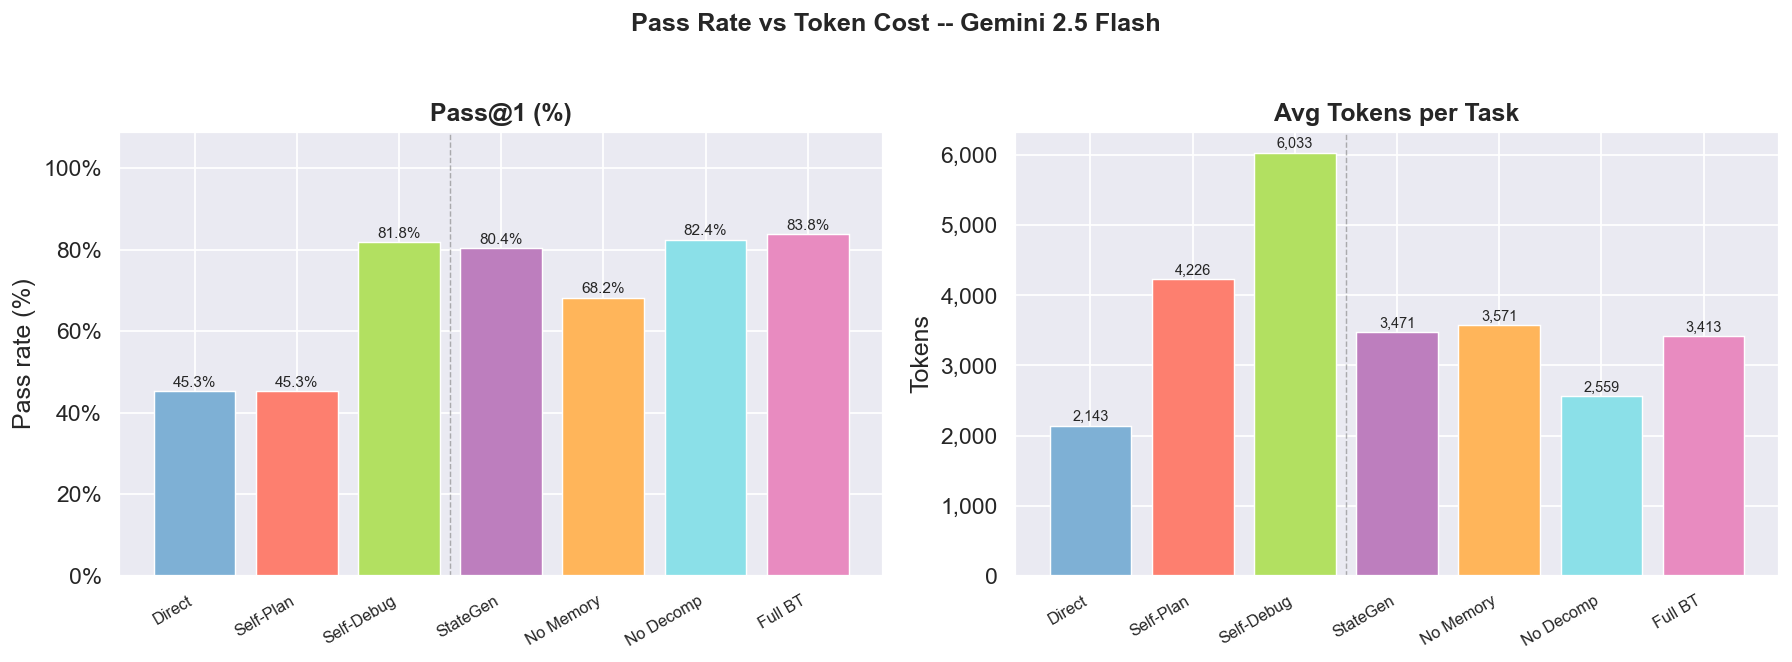

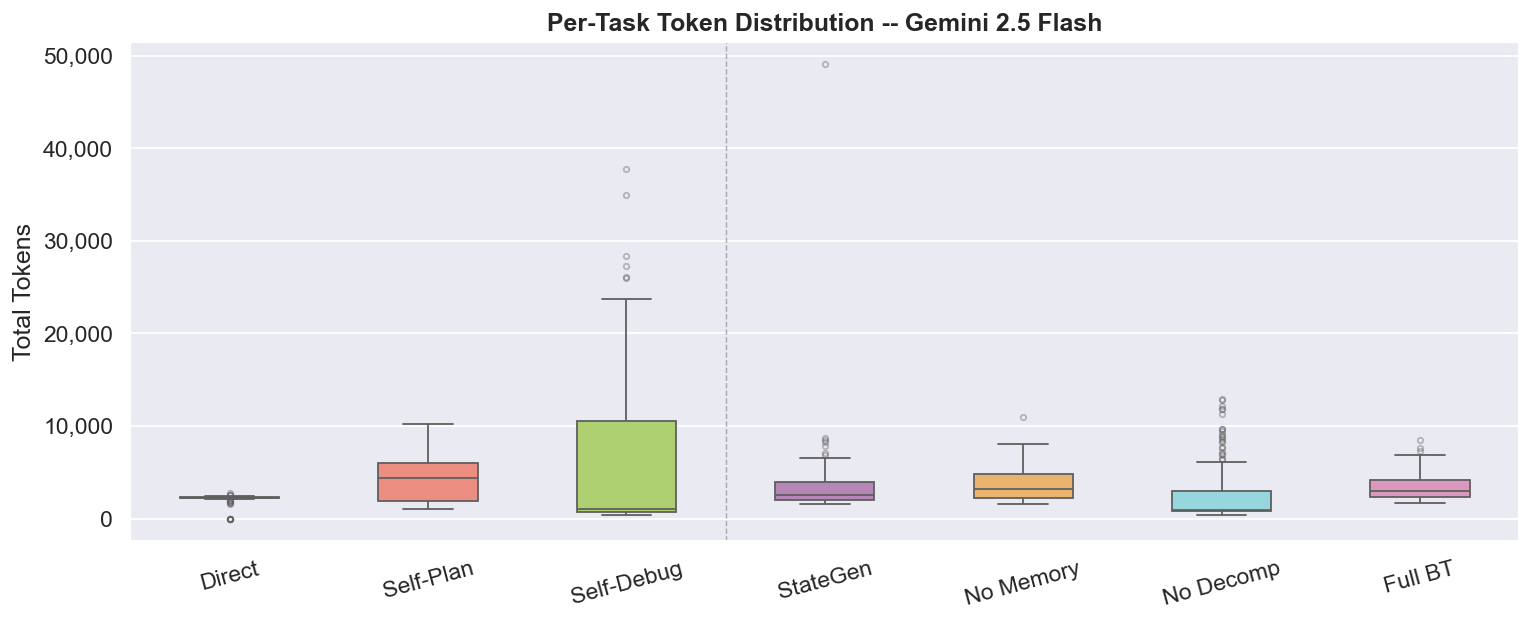

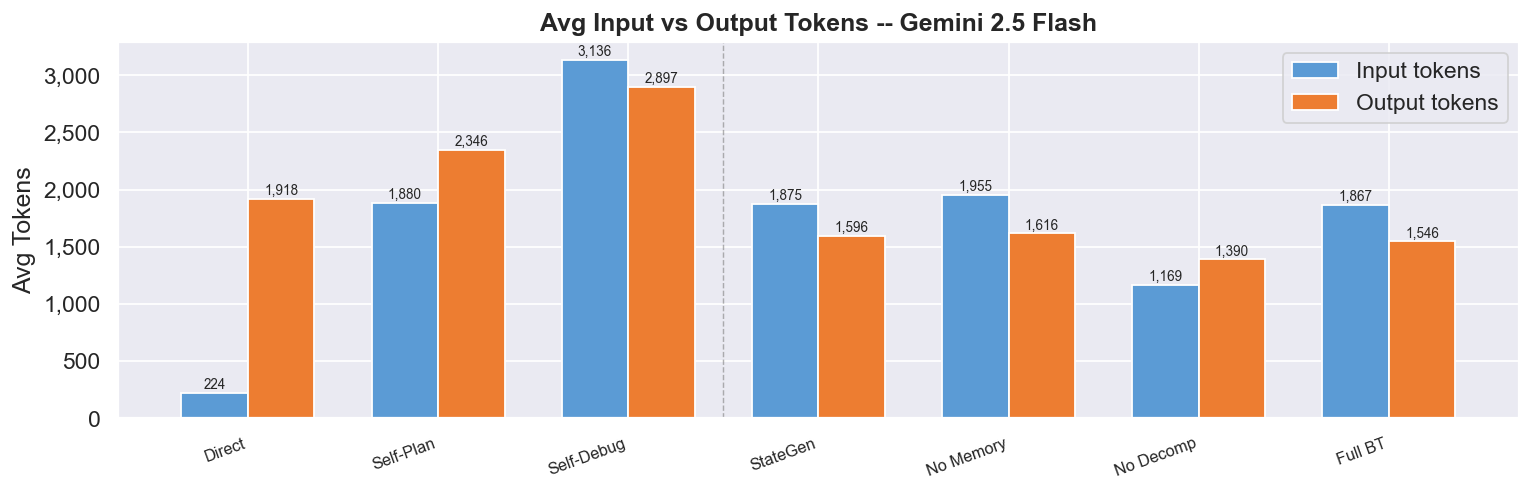

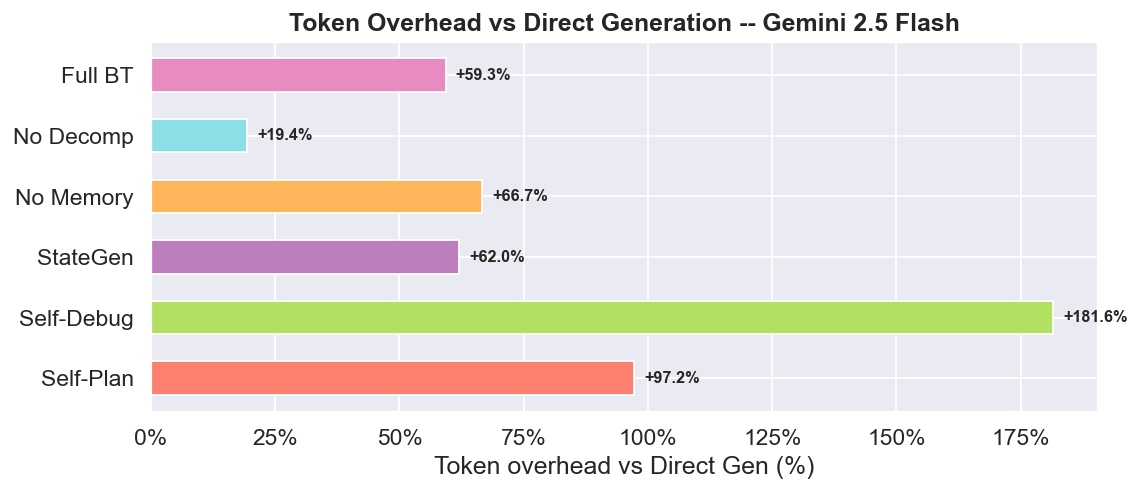

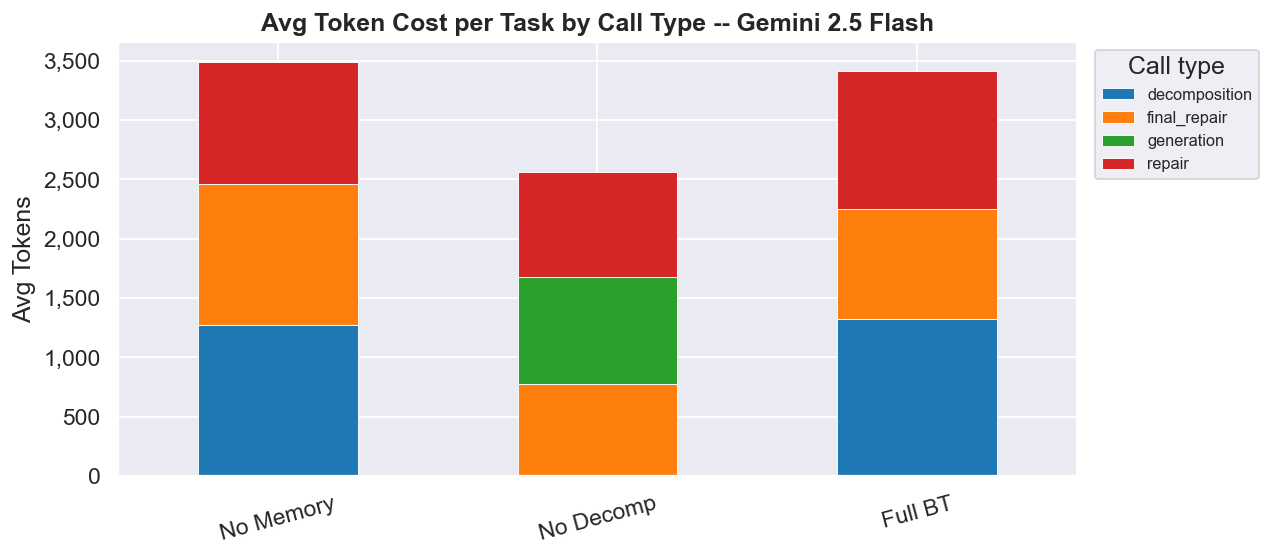

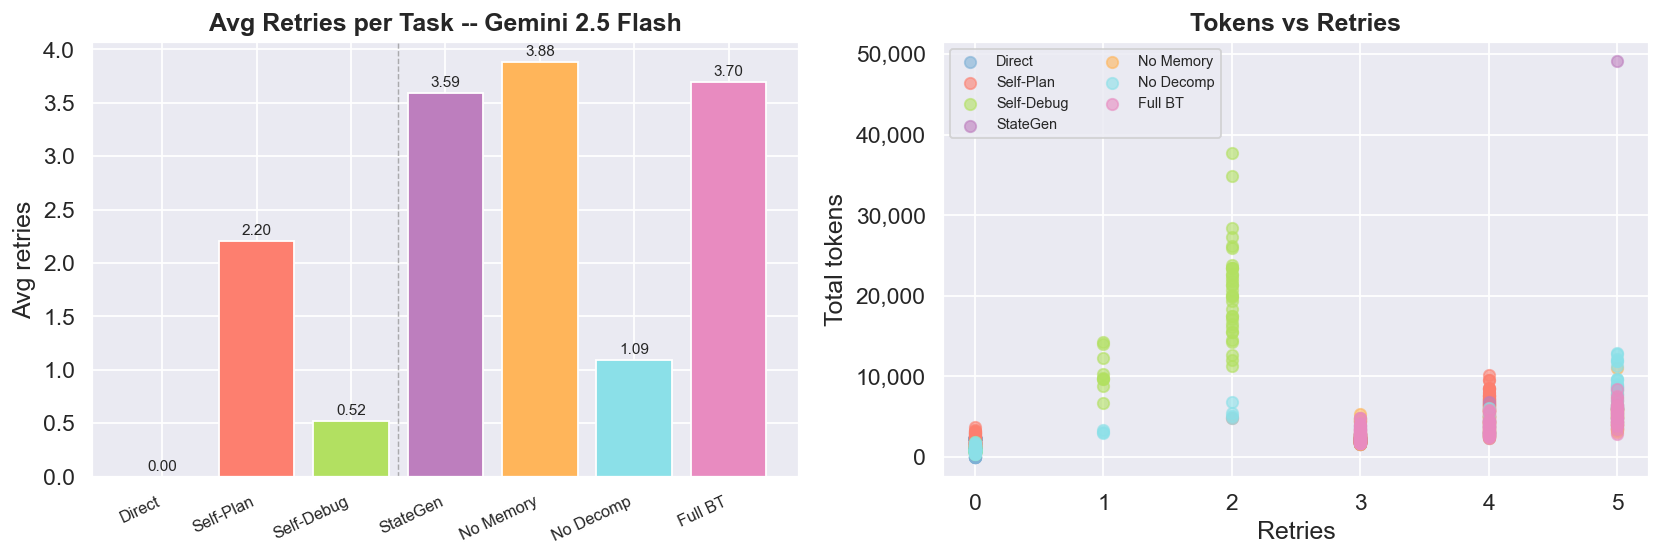

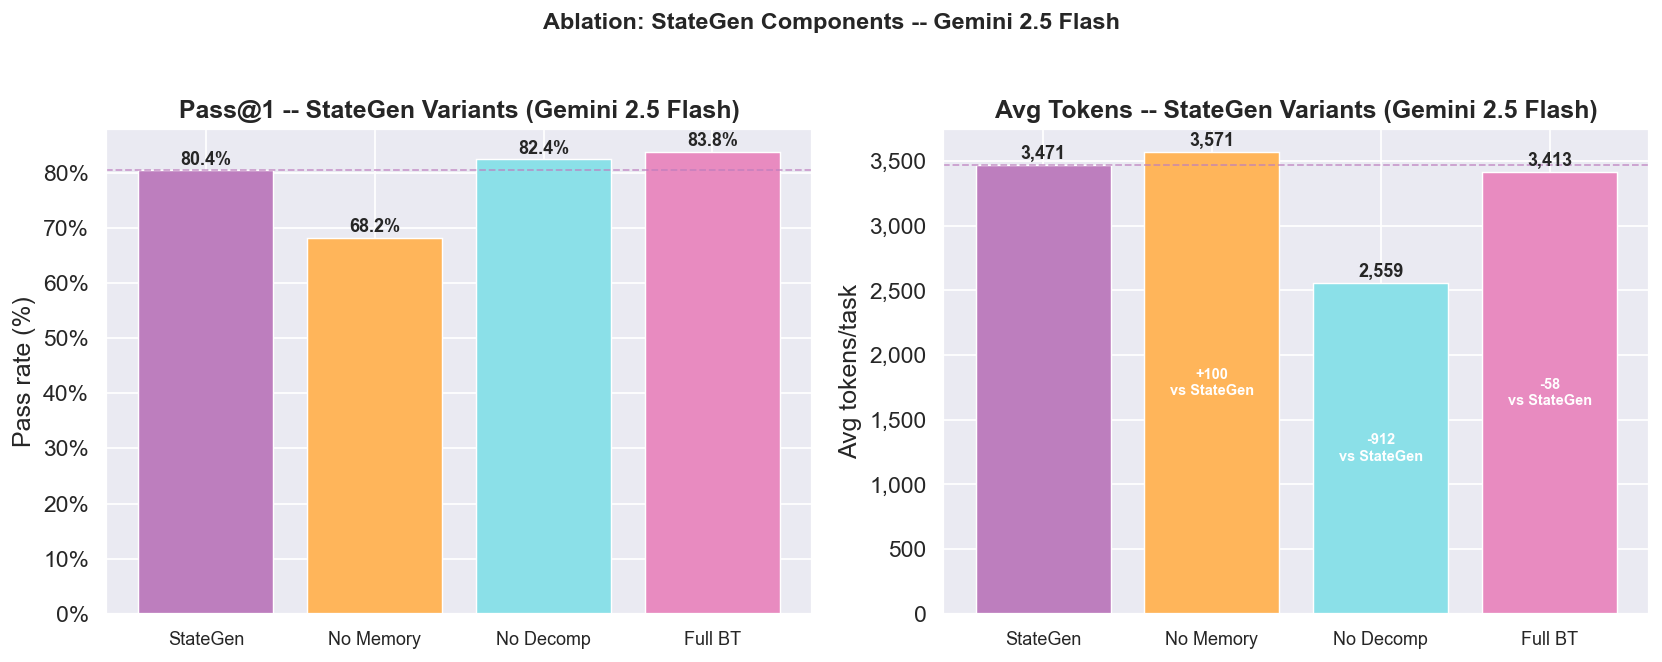

,Pass@1,Avg Tokens,Avg Input,Avg Output,Overhead vs DG,Avg Retries,Avg Time (s)
Method,,,,,,,
Direct,45.3%,"2,143",224,"1,918",baseline,0.00,23.6s
Self-Plan,45.3%,"4,226","1,880","2,346",+97.2%,2.20,33.8s
Self-Debug,81.8%,"6,033","3,136","2,897",+181.6%,0.52,34.5s
StateGen,80.4%,"3,471","1,875","1,596",+62.0%,3.59,57.2s
No Memory,68.2%,"3,571","1,955","1,616",+66.7%,3.88,52.4s
No Decomp,82.4%,"2,559","1,169","1,390",+19.4%,1.09,32.5s
Full BT,83.8%,"3,413","1,867","1,546",+59.3%,3.70,59.1s


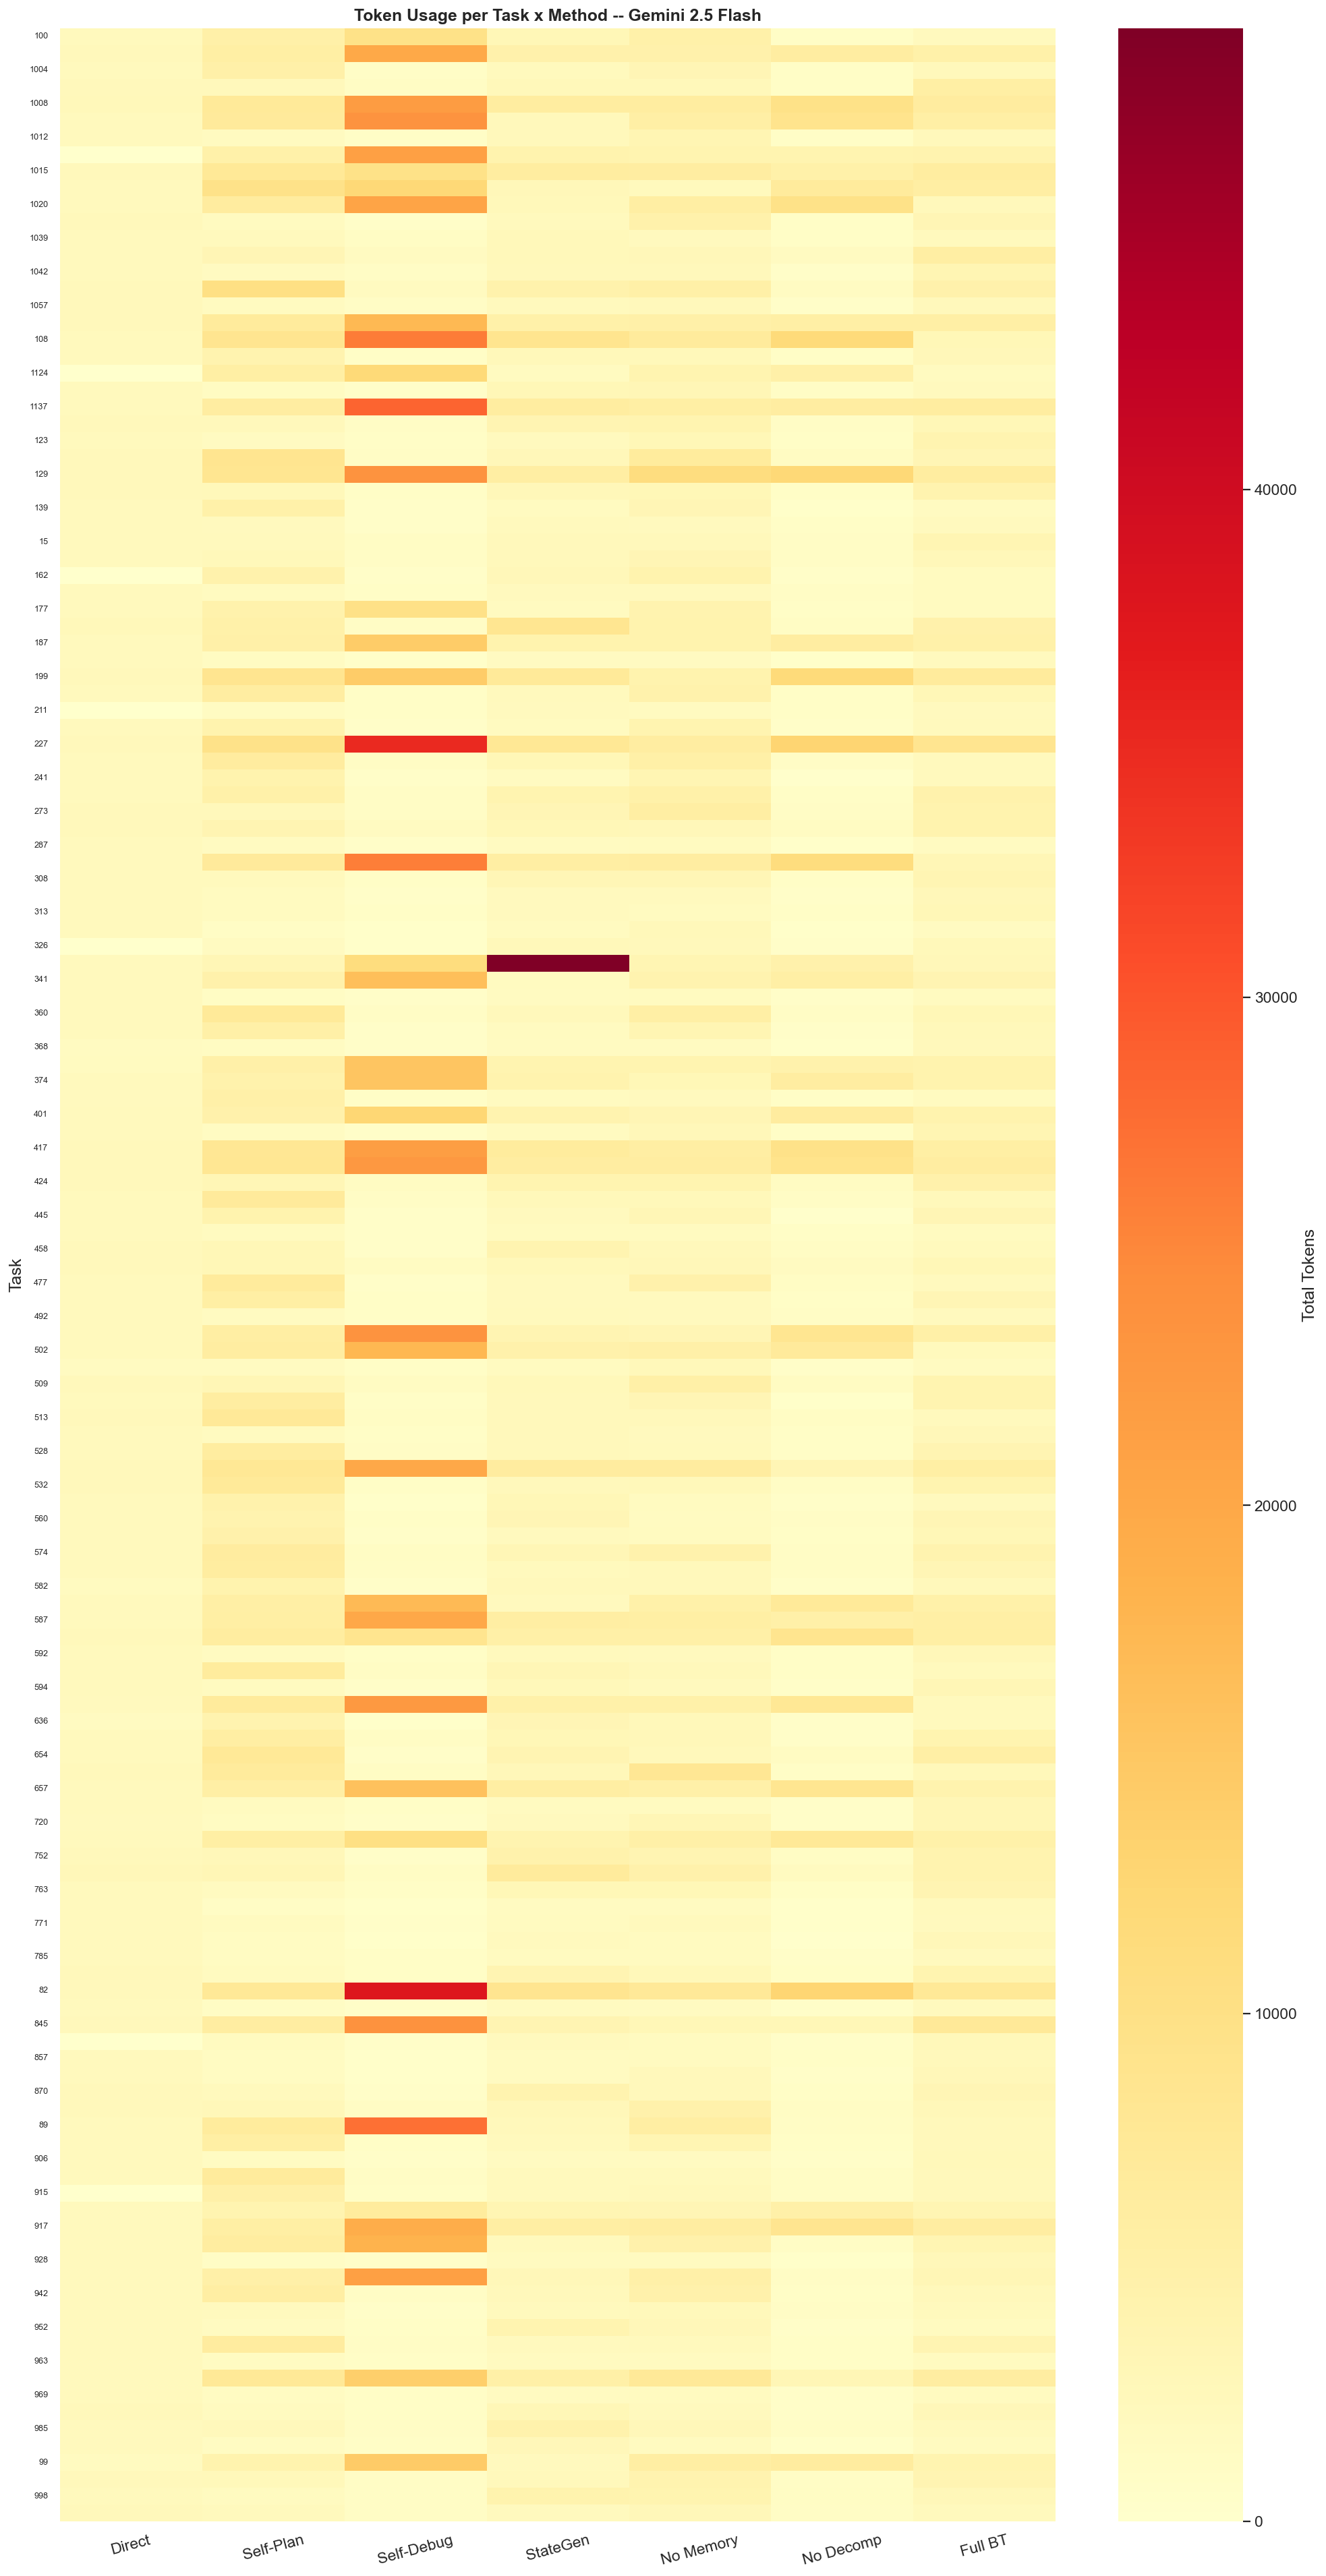

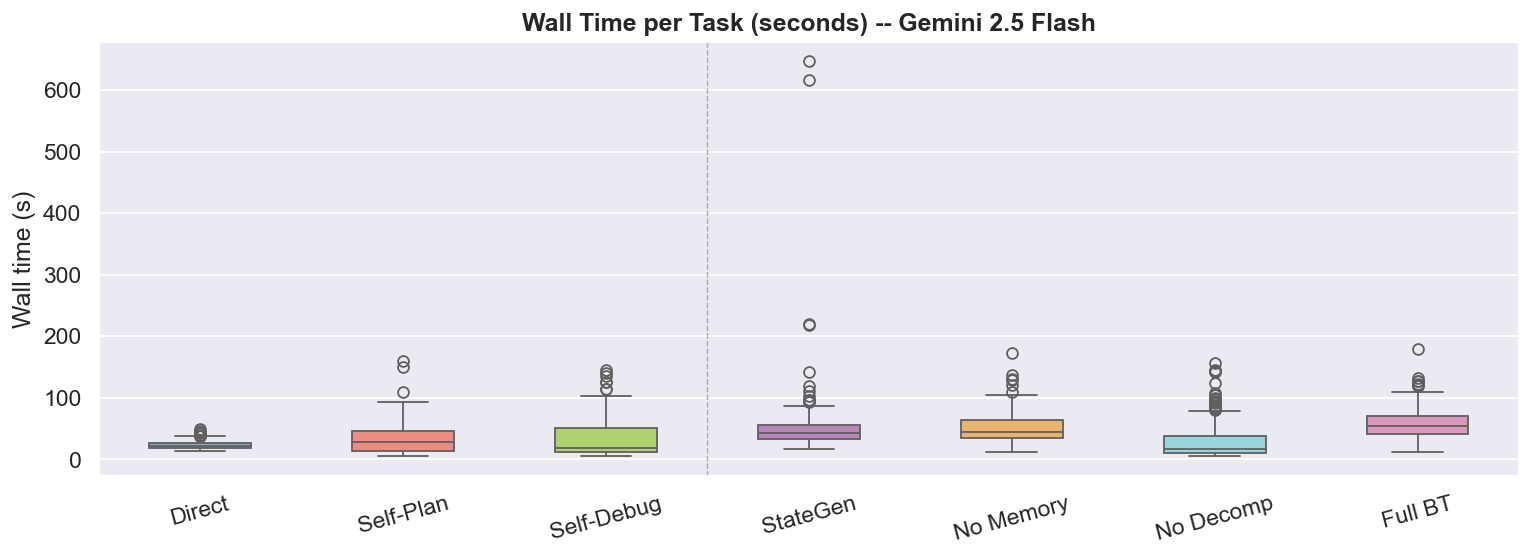

,n_tasks,avg_tokens,avg_in,avg_out,avg_retries,avg_time,pass_at_1
method,,,,,,,
direct_gen,148,2142.750000,224.317568,1918.432432,0.000000,23.564504,0.452703
self_planning,148,4225.817568,1880.270270,2345.547297,2.202703,33.795229,0.452703
self_debugging,148,6032.972973,3136.432432,2896.540541,0.520270,34.512380,0.817568
stategen,148,3471.108108,1875.135135,1595.972973,3.594595,57.236917,0.804054
stategen_no_memory,148,3571.202703,1954.864865,1616.337838,3.878378,52.376311,0.682432
stategen_no_decompose,148,2558.614865,1168.756757,1389.858108,1.094595,32.509042,0.824324
stategen_full_backtrack,148,3413.101351,1866.790541,1546.310811,3.695946,59.094511,0.837838


In [56]:
# ── Gemini Flash full analysis ───────────────────────────────────────
_vm = RESULTS.parent / "vm_results"
analyze_model(
    model_name  = "Gemini 2.5 Flash",
    results_dir = _vm / "gemini_flash",
    save_prefix = _vm / "gemini_flash" / "plot",
)

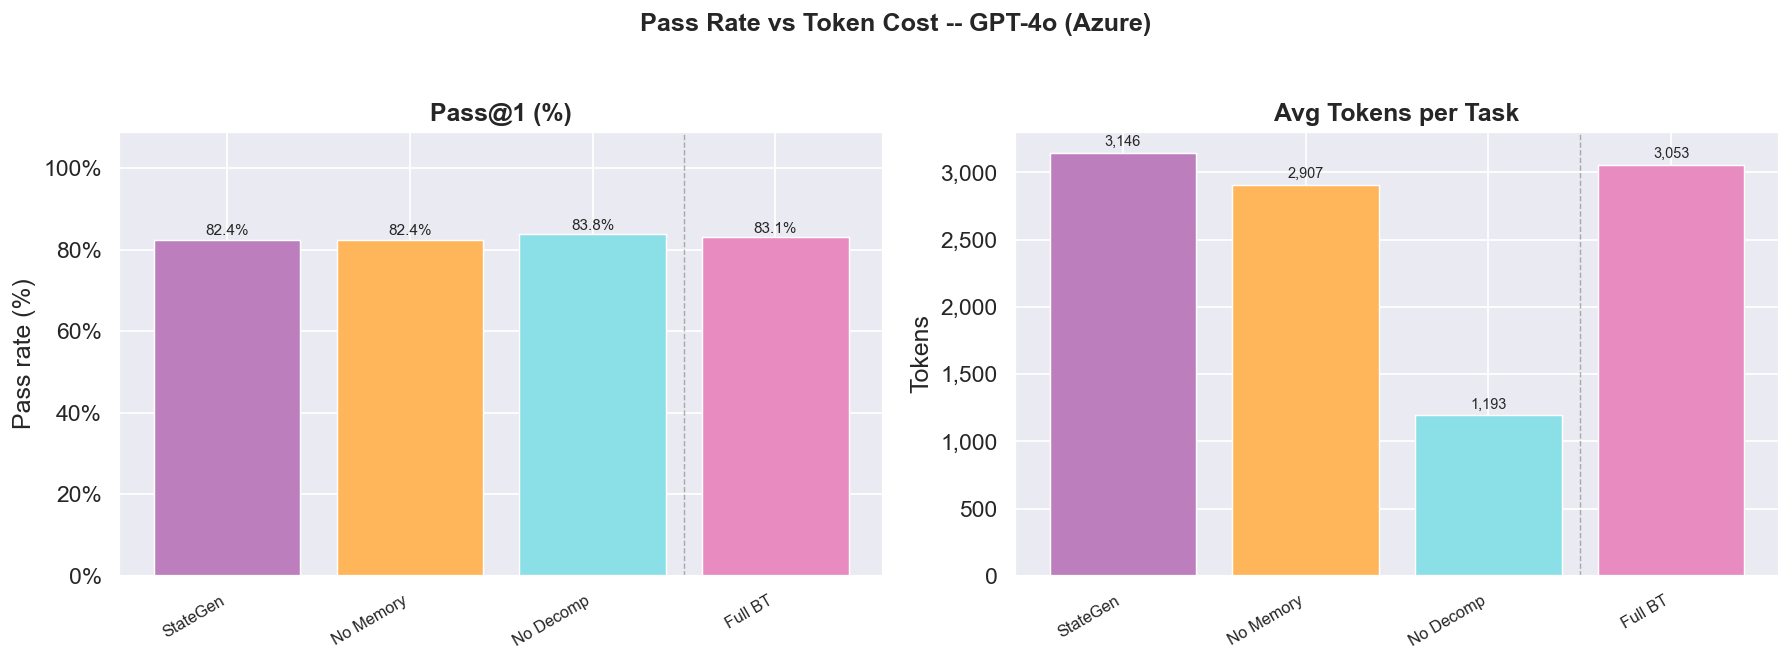

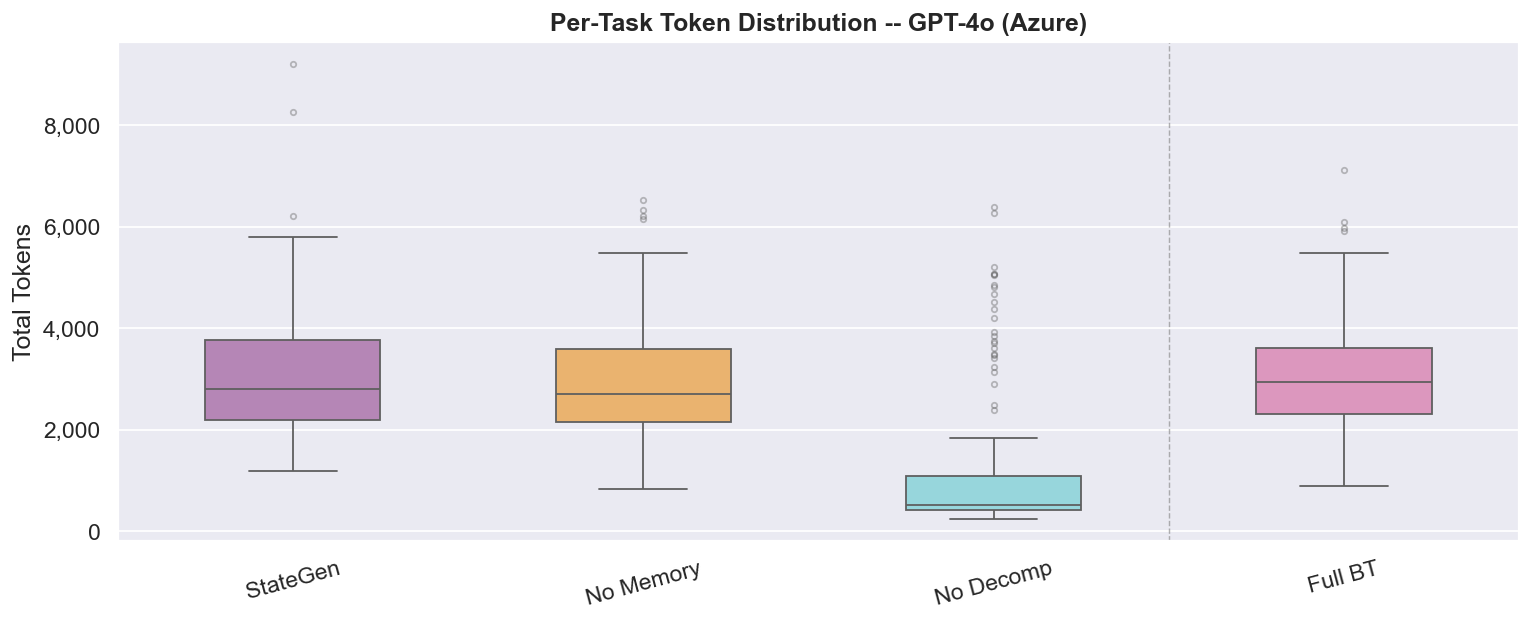

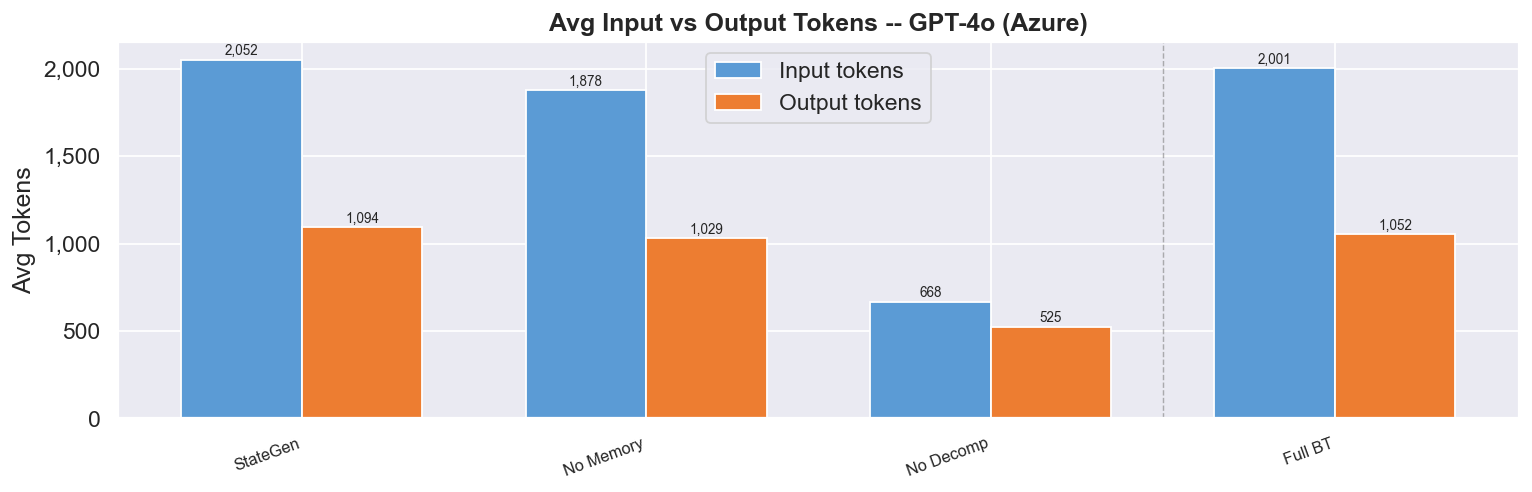

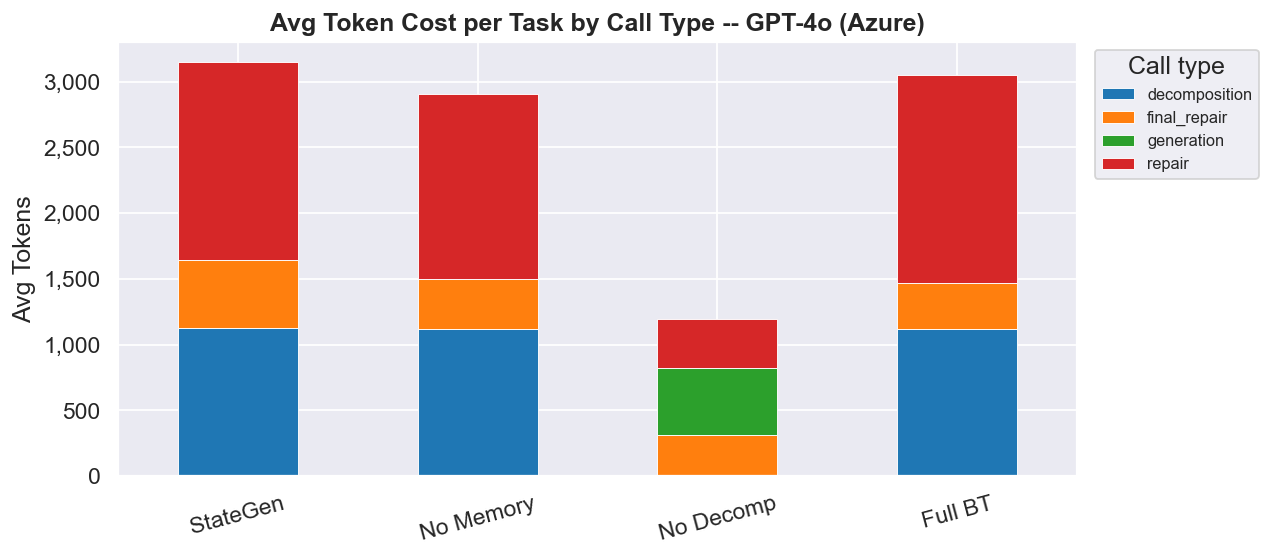

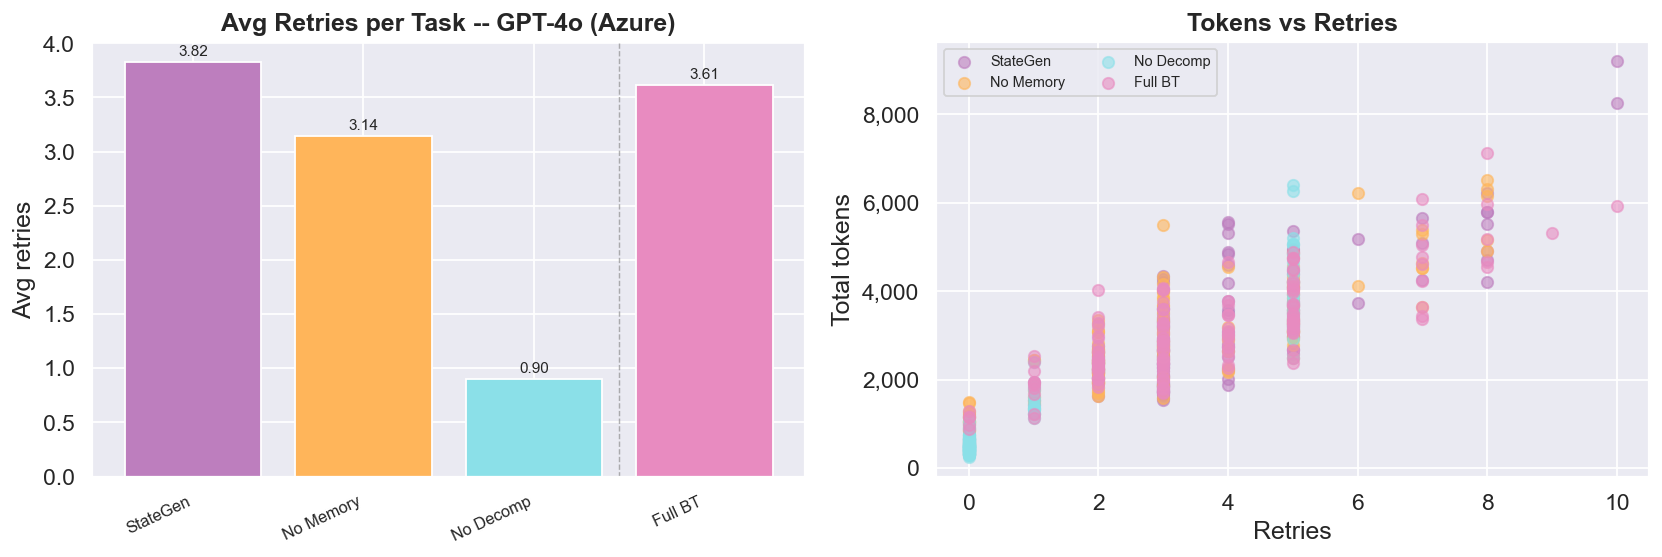

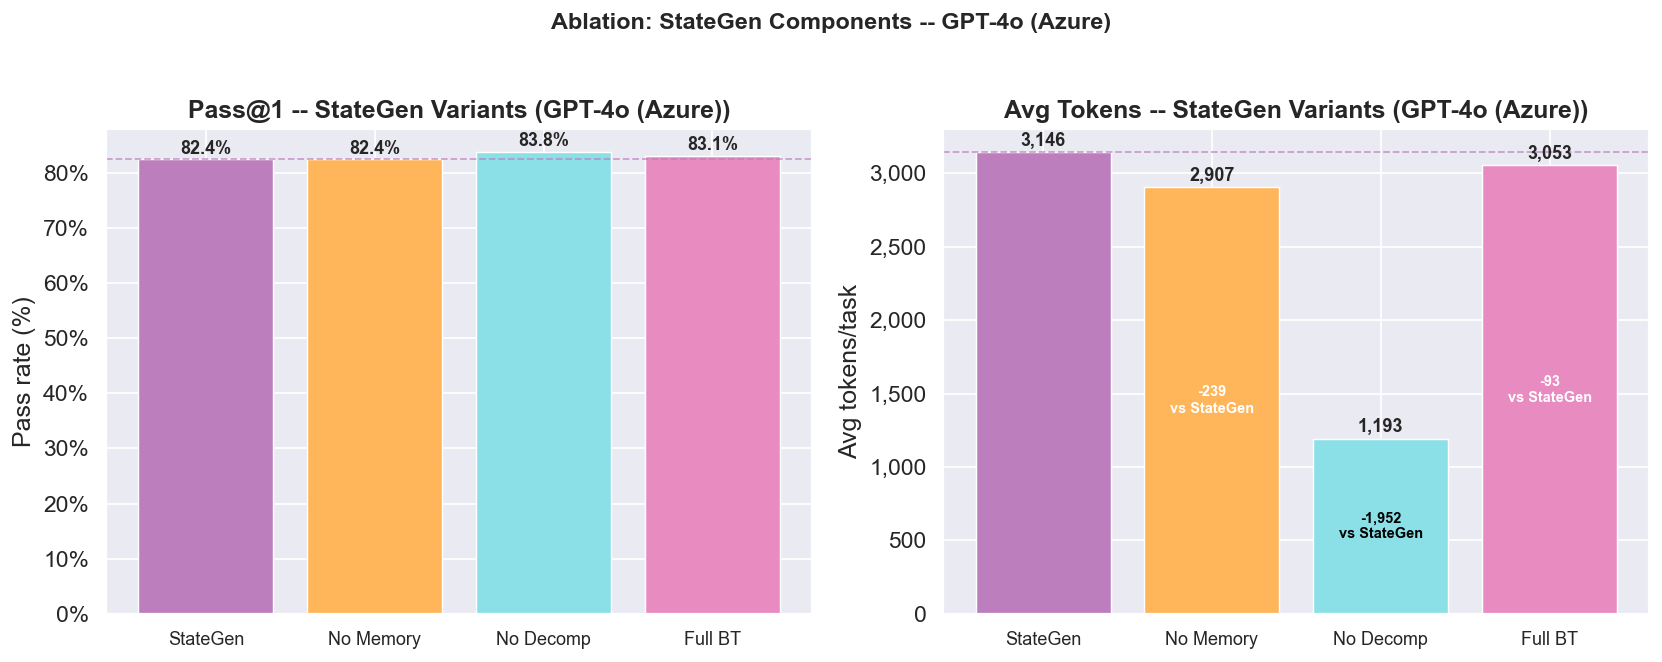

,Pass@1,Avg Tokens,Avg Input,Avg Output,Overhead vs DG,Avg Retries,Avg Time (s)
Method,,,,,,,
StateGen,82.4%,"3,146","2,052","1,094",n/a,3.82,18.7s
No Memory,82.4%,"2,907","1,878","1,029",n/a,3.14,16.2s
No Decomp,83.8%,"1,193",668,525,n/a,0.90,6.1s
Full BT,83.1%,"3,053","2,001","1,052",n/a,3.61,21.3s


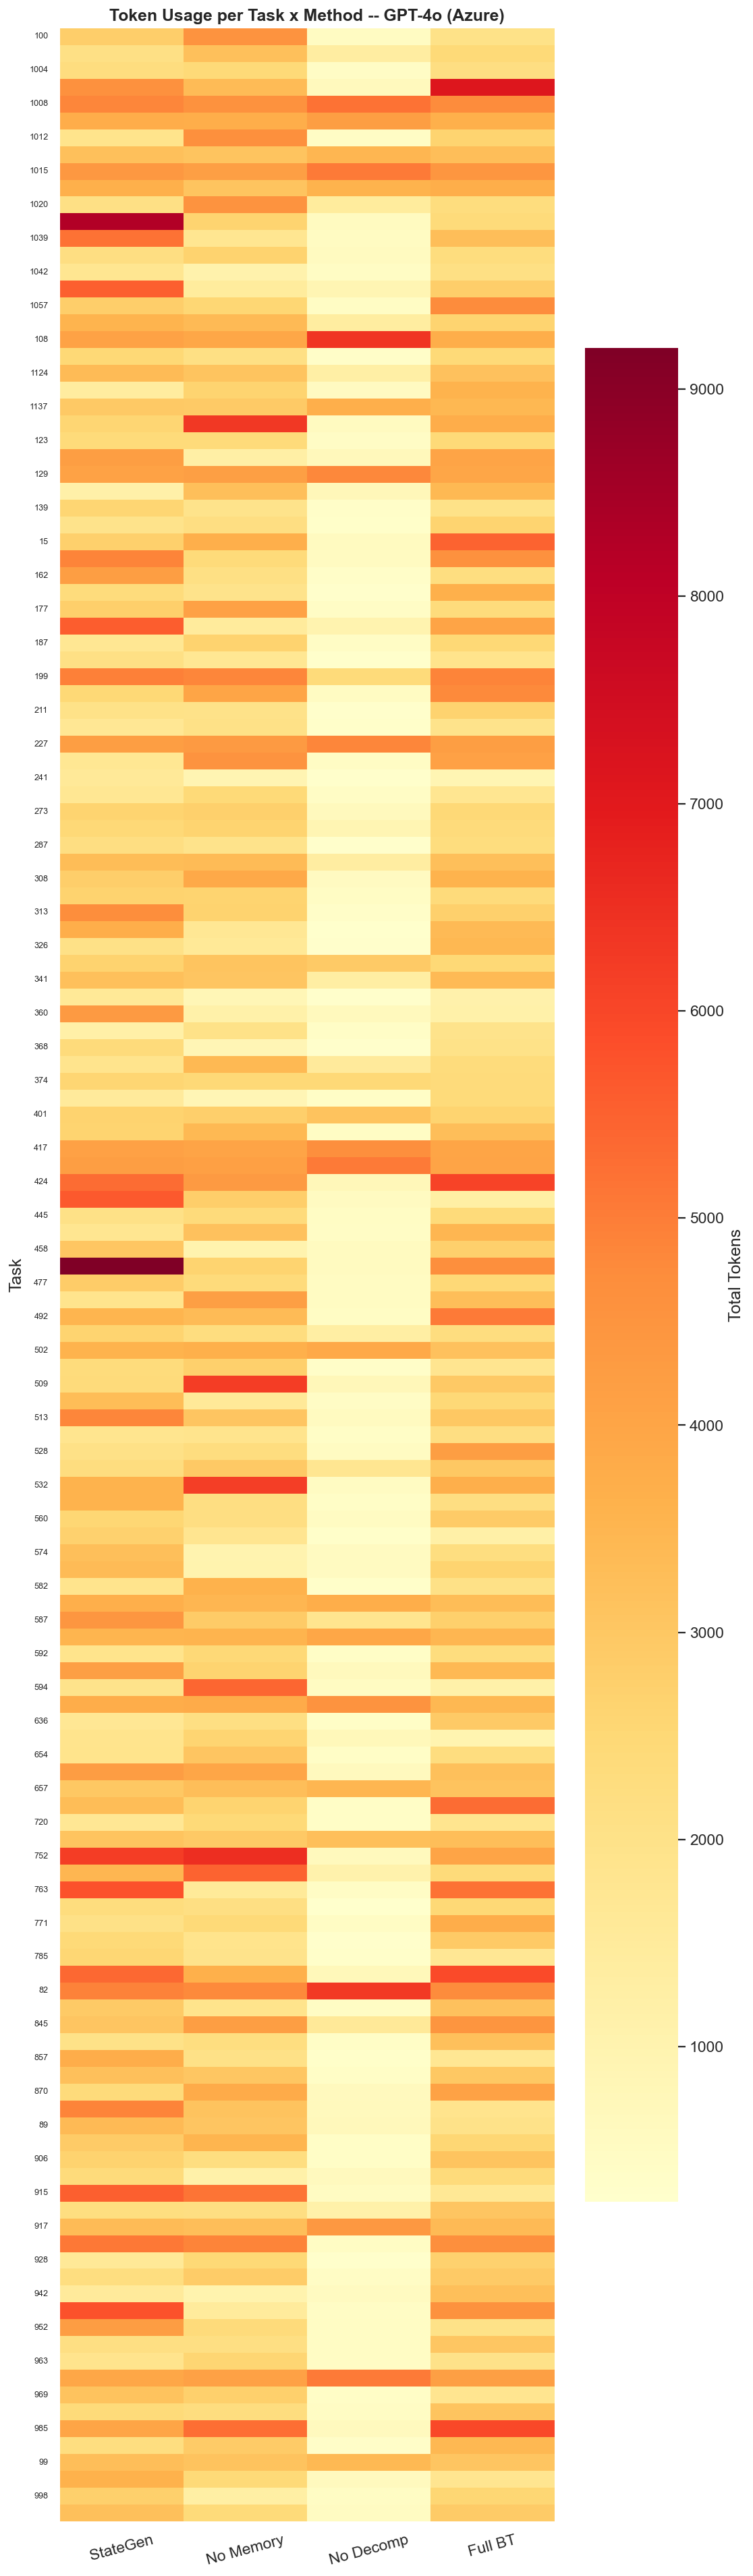

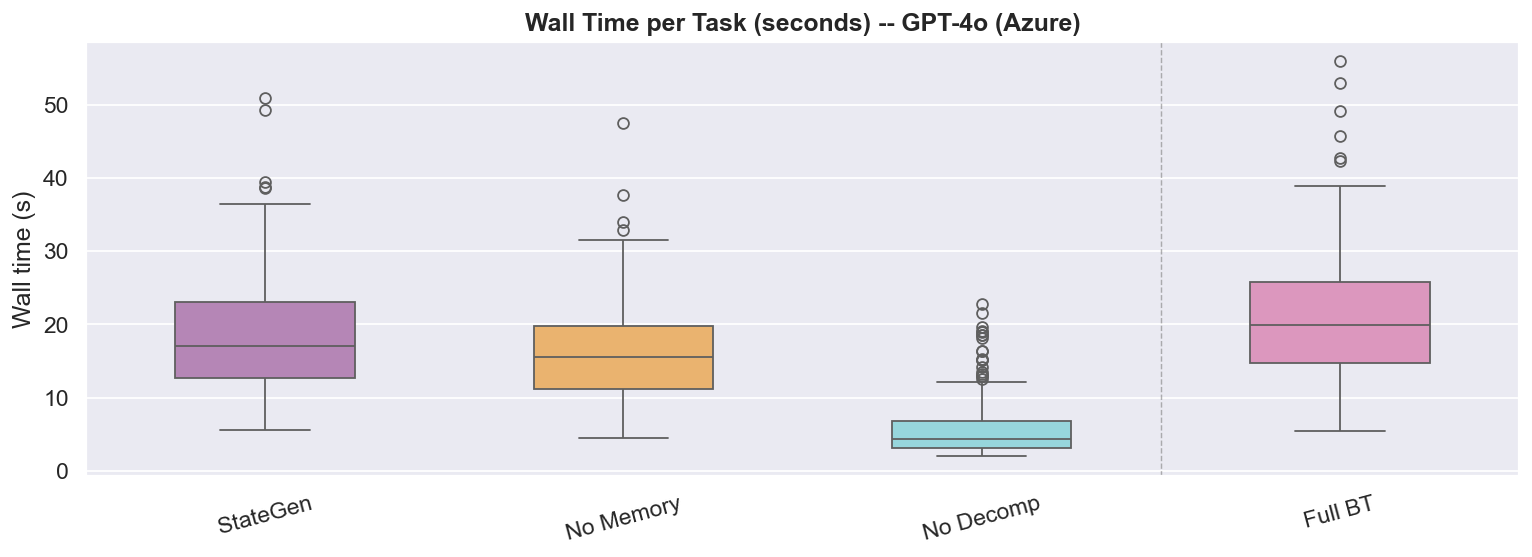

,n_tasks,avg_tokens,avg_in,avg_out,avg_retries,avg_time,pass_at_1
method,,,,,,,
stategen,148,3145.608108,2051.682432,1093.925676,3.824324,18.684807,0.824324
stategen_no_memory,148,2906.641892,1877.668919,1028.972973,3.141892,16.235179,0.824324
stategen_no_decompose,148,1193.290541,668.148649,525.141892,0.898649,6.128781,0.837838
stategen_full_backtrack,148,3052.905405,2001.094595,1051.810811,3.614865,21.310846,0.831081


In [57]:
# ── GPT-4o full analysis ──────────────────────────────────────────────
_vm = RESULTS.parent / "vm_results"
analyze_model(
    model_name  = "GPT-4o (Azure)",
    results_dir = _vm / "gpt4o_azure_v4",
    save_prefix = _vm / "gpt4o_azure_v4" / "plot",
)

## Reproducibility — Code Used to Generate These Results

The cells below provide the **Python code used to reproduce the main experiment folders** discussed in this notebook. They call the project scripts directly so that a GitHub reader can rerun the experiments from the repository root.

Before running them:

- Create and activate the project environment.
- Install dependencies from `stategen/requirements.txt`.
- Ensure the required API keys are available as environment variables (for example `OPENAI_API_KEY`, `ANTHROPIC_API_KEY`, `AZURE_OPENAI_API_KEY`, or gateway credentials depending on provider).
- If you want **official BigCodeBench scores** rather than quick-check proxy scores, start the BCB server or run `--remote_eval` after generation.


In [48]:
from pathlib import Path
import os
import subprocess
import sys

_ROOT = Path.cwd()
if not (_ROOT / "stategen").exists():
    raise RuntimeError("Run this notebook from the project root so that ./stategen exists.")

EXP = _ROOT / "stategen" / "experiments"
RESULTS_REPRO = _ROOT / "stategen" / "results"

def run(cmd, cwd=None):
    print("$", " ".join(cmd))
    subprocess.run(cmd, cwd=cwd or ROOT / "stategen", check=True)


RuntimeError: Run this notebook from the project root so that ./stategen exists.

### 1. Reproduce the DeepSeek experiment used in this notebook

This generates the `stategen/results/deepseek/` folder analyzed above.


In [49]:
run([
    sys.executable,
    str(EXP / "run_bigcodebench.py"),
    "--experiment", "deepseek",
    "--provider", "openai_compatible",
    "--model", "deepseek-coder",
    "--base_url", "https://api.deepseek.com/v1",
    "--subset", "hard",
    "--method",
    "direct_gen",
    "self_debugging",
    "self_planning",
    "stategen",
    "stategen_no_memory",
    "stategen_no_decompose",
    "stategen_full_backtrack",
])


NameError: name 'run' is not defined

### 2. Optional: run official BigCodeBench Docker evaluation for DeepSeek

This step produces the `*_eval_results.json` files used in the official-eval comparison section.


In [50]:
run([
    sys.executable,
    str(EXP / "run_bigcodebench.py"),
    "--experiment", "deepseek",
    "--provider", "openai_compatible",
    "--model", "deepseek-coder",
    "--base_url", "https://api.deepseek.com/v1",
    "--subset", "hard",
    "--method",
    "direct_gen",
    "self_debugging",
    "self_planning",
    "stategen",
    "stategen_no_memory",
    "stategen_no_decompose",
    "stategen_full_backtrack",
    "--remote_eval",
])


NameError: name 'run' is not defined

### 3. Reproduce the Gemini Flash and GPT-4o VM runs

These are the runs referenced from `results/vm_results/gemini_flash/` and `results/vm_results/gpt4o_azure_v4/`.
The Gemini Flash run includes all seven methods; the GPT-4o run includes the four StateGen-family methods only.


In [ ]:
run([
    sys.executable,
    str(EXP / "run_bigcodebench.py"),
    "--experiment", "vm_results/gemini_flash",
    "--provider", "openai_compatible",
    "--model", "gemini-2.5-flash",
    "--base_url", "https://generativelanguage.googleapis.com/v1beta/openai/",
    "--subset", "hard",
    "--method",
    "direct_gen",
    "self_debugging",
    "self_planning",
    "stategen",
    "stategen_no_memory",
    "stategen_no_decompose",
    "stategen_full_backtrack",
])


In [ ]:
run([
    sys.executable,
    str(EXP / "run_bigcodebench.py"),
    "--experiment", "vm_results/gpt4o_azure_v4",
    "--provider", "azure_openai",
    "--model", "gpt-4o-stategen",
    "--base_url", "https://stategen.openai.azure.com/",
    "--subset", "hard",
    "--method",
    "stategen",
    "stategen_no_memory",
    "stategen_no_decompose",
    "stategen_full_backtrack",
])


### 4. Recompute the cross-model comparison JSON

This reproduces the combined comparison file used for the cross-model discussion.


In [ ]:
run([
    sys.executable,
    str(EXP / "compare_models.py"),
    "--experiments",
    "results/deepseek:DeepSeek-Coder",
    "results/vm_results/gemini_flash:Gemini Flash",
    "results/vm_results/gpt4o_azure_v4:GPT-4o",
    "--methods",
    "stategen",
    "stategen_no_memory",
    "stategen_no_decompose",
    "stategen_full_backtrack",
    "--output",
    "results/cross_model.json",
])


### Notes

- If you want to debug a single task before committing to a full run, use `experiments/debug_one.py`.
- The VM results referenced in this notebook are **proxy runs** unless official evaluation is requested separately.
- If an experiment is interrupted, `run_bigcodebench.py` supports crash recovery through existing solution files in the output directory.
